In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pyspark.sql import functions as F
from pyspark.sql.types import *
warnings.filterwarnings('ignore')


In [0]:
# Load US Flights 2023 data into Spark DataFrame
flights_df = spark.read.table("workspace.default.us_flights_2023")
geolocation_df = spark.read.table('workspace.default.airports_geolocation')
cancelled_df = spark.read.table('workspace.default.cancelled_diverted_2023')
weather_df = spark.read.table('workspace.default.weather_meteo_by_airport')


In [0]:

print("✅ All datasets loaded successfully")
print(f"   Flights:       {flights_df.count():>10,} rows  |  {len(flights_df.columns)} columns")
print(f"   Geolocation:   {geolocation_df.count():>10,} rows  |  {len(geolocation_df.columns)} columns")
print(f"   Cancelled:     {cancelled_df.count():>10,} rows  |  {len(cancelled_df.columns)} columns")
print(f"   Weather:       {weather_df.count():>10,} rows  |  {len(weather_df.columns)} columns")

✅ All datasets loaded successfully
   Flights:        6,743,404 rows  |  24 columns
   Geolocation:          364 rows  |  7 columns
   Cancelled:        104,488 rows  |  23 columns
   Weather:          132,860 rows  |  10 columns


In [0]:
flights_count = flights_df.count()

missing_stats = []
for col_name in flights_df.columns:
    null_count = flights_df.where(F.col(col_name).isNull()).count()
    missing_stats.append({
        'column': col_name,
        'null_count': null_count,
        'null_pct': round(null_count / flights_count * 100, 2)
    })

missing_pd = pd.DataFrame(missing_stats).sort_values('null_pct', ascending=False)
print("Missing Values in Flights Table:")
print(missing_pd.to_string(index=False))

Missing Values in Flights Table:
            column  null_count  null_pct
        FlightDate           0       0.0
       Day_Of_Week           0       0.0
             Model           0       0.0
      Manufacturer           0       0.0
Delay_LastAircraft           0       0.0
    Delay_Security           0       0.0
         Delay_NAS           0       0.0
     Delay_Weather           0       0.0
     Delay_Carrier           0       0.0
     Distance_type           0       0.0
   Flight_Duration           0       0.0
    Arr_Delay_Type           0       0.0
         Arr_Delay           0       0.0
      Arr_CityName           0       0.0
       Arr_Airport           0       0.0
    Dep_Delay_Type           0       0.0
     Dep_Delay_Tag           0       0.0
         Dep_Delay           0       0.0
     DepTime_label           0       0.0
      Dep_CityName           0       0.0
       Dep_Airport           0       0.0
       Tail_Number           0       0.0
           Airline      

In [0]:
#SAMPLE_FRACTION = 0.5

#flights_sampled = flights_df.sample(withReplacement=False, #fraction=float(SAMPLE_FRACTION), seed=42)
pdf = flights_df.toPandas()
#print(f"Sampled {len(pdf):,} rows ({SAMPLE_FRACTION*100:.0f}% of full dataset) for EDA")
print(f"Shape: {pdf.shape}")
pdf.info()

---------------------------------------------------------------------------
SparkException                            Traceback (most recent call last)
File <command-8692900145120779>, line 4
      1 #SAMPLE_FRACTION = 0.5
      2 
      3 #flights_sampled = flights_df.sample(withReplacement=False, #fraction=float(SAMPLE_FRACTION), seed=42)
----> 4 pdf = flights_df.toPandas()
      5 #print(f"Sampled {len(pdf):,} rows ({SAMPLE_FRACTION*100:.0f}% of full dataset) for EDA")
      6 print(f"Shape: {pdf.shape}")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:1943, in DataFrame.toPandas(self)
   1941 def toPandas(self) -> "PandasDataFrameLike":
   1942     query = self._plan.to_proto(self._session.client)
-> 1943     pdf, ei = self._session.client.to_pandas(query, self._plan.observations)
   1944     self._execution_info = ei
   1945     return pdf

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1386, in SparkC

In [0]:
delay_cols_candidates = [c for c in pdf.columns if 'delay' in c.lower() or 'DEP_DEL' in c or 'ARR_DEL' in c]
print("Potential delay columns:", delay_cols_candidates)

# Identify time columns
time_cols_candidates = [c for c in pdf.columns if 'time' in c.lower() or 'date' in c.lower() or 'TIME' in c or 'DATE' in c]
print("Potential time/date columns:", time_cols_candidates)

Potential delay columns: ['Dep_Delay', 'Dep_Delay_Tag', 'Dep_Delay_Type', 'Arr_Delay', 'Arr_Delay_Type', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft']
Potential time/date columns: ['FlightDate', 'DepTime_label']


In [0]:
pdf.columns = pdf.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('.', '_', regex=False)
print("Cleaned columns:")
print(pdf.columns.tolist())

Cleaned columns:
['flightdate', 'day_of_week', 'airline', 'tail_number', 'dep_airport', 'dep_cityname', 'deptime_label', 'dep_delay', 'dep_delay_tag', 'dep_delay_type', 'arr_airport', 'arr_cityname', 'arr_delay', 'arr_delay_type', 'flight_duration', 'distance_type', 'delay_carrier', 'delay_weather', 'delay_nas', 'delay_security', 'delay_lastaircraft', 'manufacturer', 'model', 'aicraft_age']


In [0]:
arr_delay_col = None
for c in pdf.columns:
    if 'arr' in c and 'del' in c and ('15' in c or 'min' not in c):
        arr_delay_col = c
        break
if arr_delay_col is None:
    # fallback: any column with arr and delay
    for c in pdf.columns:
        if 'arr' in c and 'del' in c:
            arr_delay_col = c
            break

dep_delay_col = None
for c in pdf.columns:
    if 'dep' in c and 'del' in c and ('15' in c or 'min' not in c):
        dep_delay_col = c
        break
if dep_delay_col is None:
    for c in pdf.columns:
        if 'dep' in c and 'del' in c:
            dep_delay_col = c
            break

print(f"Arrival delay column:   {arr_delay_col}")
print(f"Departure delay column: {dep_delay_col}")

Arrival delay column:   arr_delay
Departure delay column: dep_delay


In [0]:
desc = pdf.describe(include='number').T
desc['missing_%'] = (pdf.isnull().sum() / len(pdf) * 100).round(2)
display(desc)

count,mean,std,min,25%,50%,75%,max,missing_%
3371076.0,3.982622759024122,2.0015825514465364,1.0,2.0,4.0,6.0,7.0,0.0
3371076.0,12.204278989853684,55.0515600958261,-99.0,-5.0,-2.0,9.0,3024.0,0.0
3371076.0,0.378989082417602,0.4851354734940303,0.0,0.0,0.0,1.0,1.0,0.0
3371076.0,6.632870929044613,57.05749408999114,-98.0,-15.0,-6.0,9.0,3063.0,0.0
3371076.0,140.29484769847966,72.85922901334935,0.0,87.0,124.0,171.0,749.0,0.0
3371076.0,5.188560863059747,36.552000596029316,0.0,0.0,0.0,0.0,3024.0,0.0
3371076.0,0.7430111335371852,14.379498742407996,0.0,0.0,0.0,0.0,1860.0,0.0
3371076.0,2.568763801231417,15.06991325366413,0.0,0.0,0.0,0.0,1708.0,0.0
3371076.0,0.031152961250354487,1.7120290489713337,0.0,0.0,0.0,0.0,1183.0,0.0
3371076.0,5.664693409463329,30.239068029219364,0.0,0.0,0.0,0.0,2530.0,0.0


In [0]:
cat_cols = pdf.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_cols[:10]:  # show first 10
    print(f"\n--- {c} ---")
    print(f"  Unique values: {pdf[c].nunique()}")
    print(pdf[c].value_counts().head(10).to_string())


--- flightdate ---
  Unique values: 365
flightdate
2023-10-16    10261
2023-09-28    10224
2023-10-02    10220
2023-10-19    10195
2023-09-22    10194
2023-11-26    10193
2023-10-13    10171
2023-10-12    10167
2023-10-06    10151
2023-09-21    10146

--- airline ---
  Unique values: 15
airline
Southwest Airlines Co.          710445
Delta Air Lines Inc             486702
American Airlines Inc.          464130
United Air Lines Inc.           359944
Skywest Airlines Inc.           332205
Republic Airways                143054
JetBlue Airways                 133785
Spirit Air Lines                129728
Alaska Airlines Inc.            121245
American Eagle Airlines Inc.    112385

--- tail_number ---
  Unique values: 5960
tail_number
N486HA    1648
N488HA    1633
N479HA    1629
N485HA    1628
N487HA    1608
N495HA    1607
N483HA    1589
N484HA    1589
N480HA    1581
N475HA    1579

--- dep_airport ---
  Unique values: 350
dep_airport
ATL    166516
DEN    142357
DFW    140025
ORD    12758

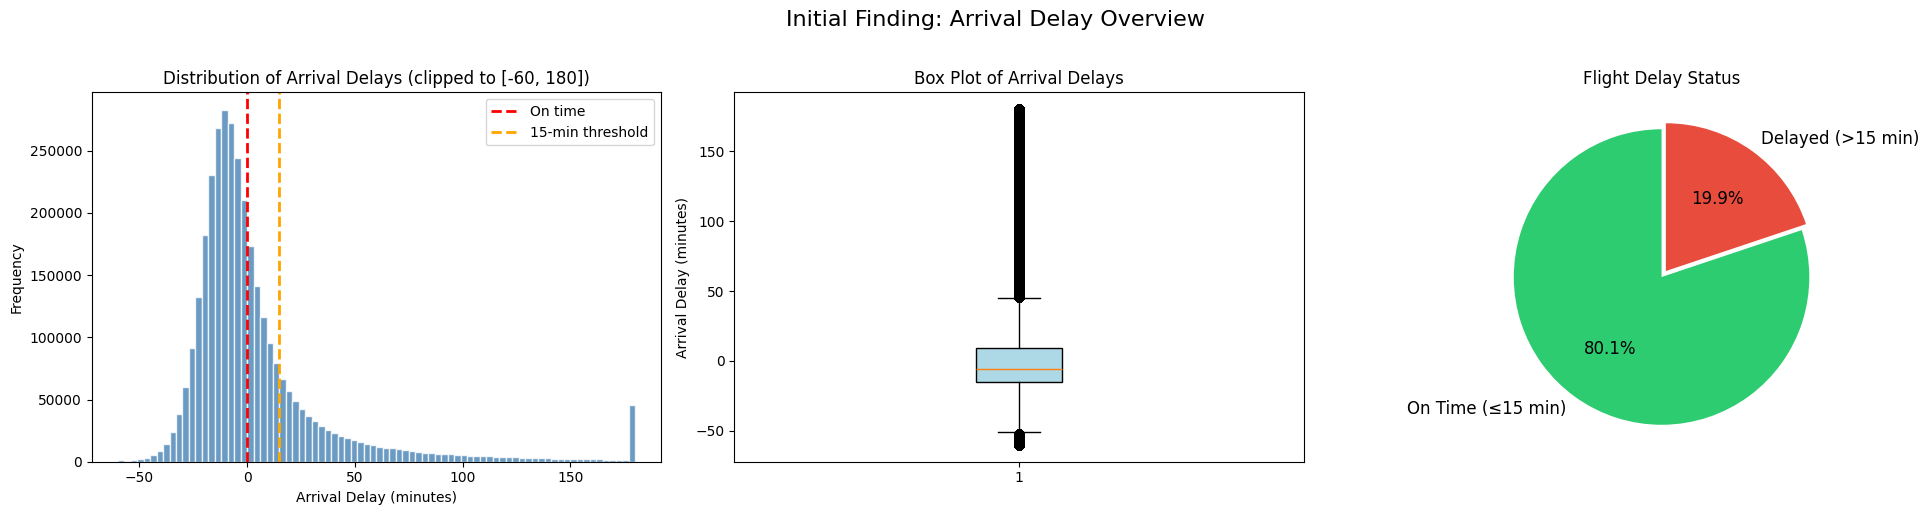


📊 Key Delay Statistics:
   Mean arrival delay:   6.6 min
   Median arrival delay: -6.0 min
   Std deviation:        57.1 min
   % flights delayed >15 min: 19.9%
   % flights early/on-time:   80.1%
   Max delay: 3063 min  |  Max early: -98 min


In [0]:
if arr_delay_col and arr_delay_col in pdf.columns:
    delay_data = pdf[arr_delay_col].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Histogram
    axes[0].hist(delay_data.clip(-60, 180), bins=80, color='navy', edgecolor='white', alpha=0.8)
    axes[0].axvline(x=0, color='lightgray', linestyle='--', linewidth=2, label='On time') 
    axes[0].axvline(x=15, color='gold', linestyle='--', linewidth=2, label='15-min threshold') 
    axes[0].set_xlabel("Arrival Delay (minutes)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of Arrival Delays (clipped to [-60, 180])")
    axes[0].legend()

    # Box plot
    axes[1].boxplot(delay_data.clip(-60, 180), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='navy', color='navy'),
                    capprops=dict(color='navy', linewidth=1.5),
                    whiskerprops=dict(color='navy', linewidth=1.5),
                    flierprops=dict(markeredgecolor='navy', markerfacecolor='navy', alpha=0.5, markersize=4),
                    medianprops=dict(color='gold', linewidth=2.5))
    axes[1].set_ylabel("Arrival Delay (minutes)")
    axes[1].set_title("Box Plot of Arrival Delays")

    # Pie chart: on-time vs delayed
    delayed = (delay_data > 15).sum()
    on_time = (delay_data <= 15).sum()
    
    wedges, texts, autotexts = axes[2].pie([on_time, delayed], labels=['On Time (≤15 min)', 'Delayed (>15 min)'],
                                           autopct='%1.1f%%', colors=['navy', 'gold'], startangle=90,
                                           explode=(0, 0.05), textprops={'fontsize': 12})
    
    autotexts[0].set_color('white')
    autotexts[1].set_color('black') 
    
    axes[2].set_title("Flight Delay Status")

    plt.suptitle("Initial Finding: Arrival Delay Overview", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Key stats
    print(f"\n📊 Key Delay Statistics:")
    print(f"   Mean arrival delay:   {delay_data.mean():.1f} min")
    print(f"   Median arrival delay: {delay_data.median():.1f} min")
    print(f"   Std deviation:        {delay_data.std():.1f} min")
    print(f"   % flights delayed >15 min: {delayed / len(delay_data) * 100:.1f}%")
    print(f"   % flights early/on-time:   {on_time / len(delay_data) * 100:.1f}%")
    print(f"   Max delay: {delay_data.max():.0f} min  |  Max early: {delay_data.min():.0f} min")
else:
    print("⚠️ Arrival delay column not found. Available columns:", pdf.columns.tolist())

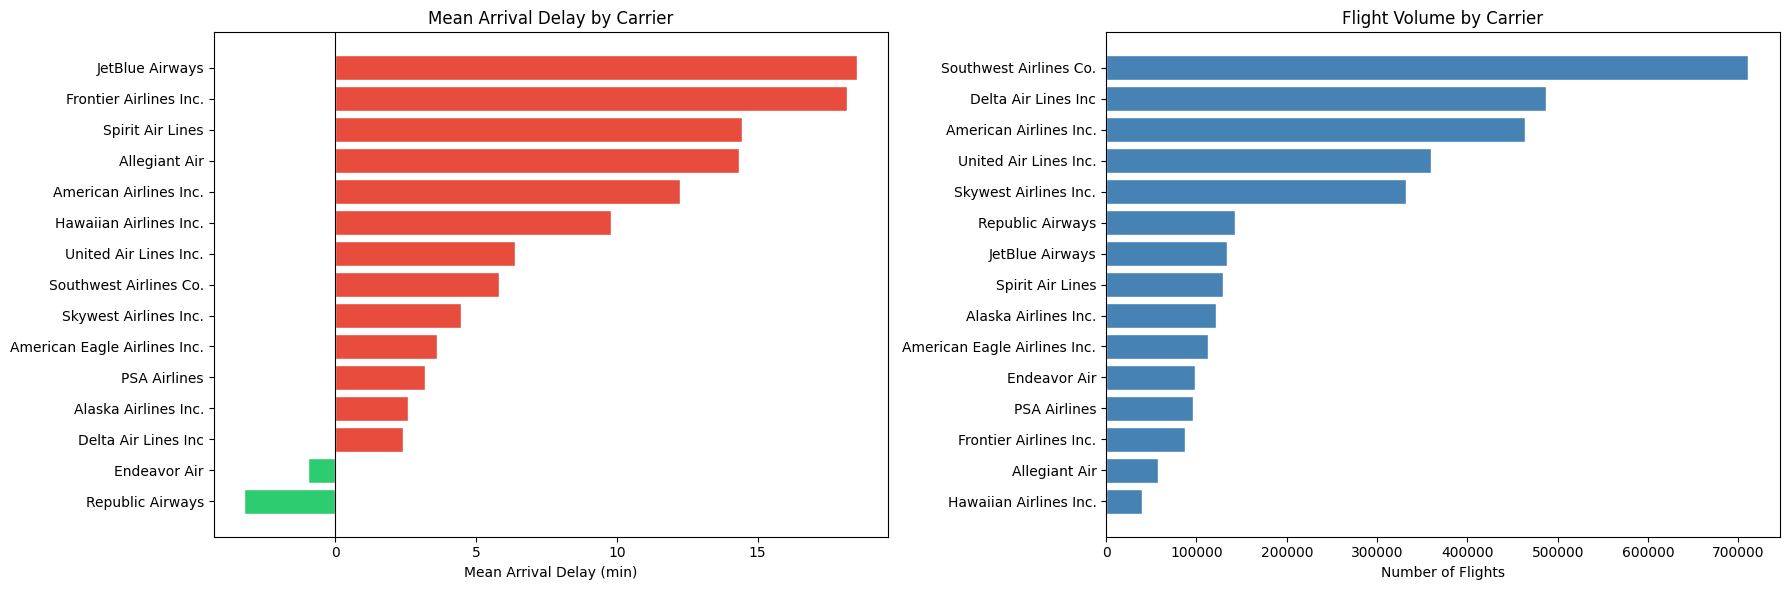


Carrier Delay Statistics:
                     Carrier  Mean Delay  Median Delay  Flight Count
             JetBlue Airways   18.529693          -3.0        133785
      Frontier Airlines Inc.   18.188722          -1.0         86789
            Spirit Air Lines   14.455330          -2.0        129728
               Allegiant Air   14.337287          -3.0         56996
      American Airlines Inc.   12.247381          -5.0        464130
      Hawaiian Airlines Inc.    9.800625           1.0         39980
       United Air Lines Inc.    6.392950          -7.0        359944
      Southwest Airlines Co.    5.803879          -3.0        710445
       Skywest Airlines Inc.    4.447841          -7.0        332205
American Eagle Airlines Inc.    3.612760          -6.0        112385
                PSA Airlines    3.190986          -8.0         95646
        Alaska Airlines Inc.    2.561697          -5.0        121245
         Delta Air Lines Inc    2.403004          -8.0        486702
       

In [0]:
carrier_col = None
for c in pdf.columns:
    if 'airline' in c or 'carrier' in c or 'op_unique' in c or 'mkt_unique' in c:
        carrier_col = c
        break
# fallback
if carrier_col is None:
    for c in pdf.columns:
        if pdf[c].dtype == 'object' and 2 <= pdf[c].str.len().mean() <= 3:
            carrier_col = c
            break

if carrier_col and arr_delay_col:
    carrier_stats = pdf.groupby(carrier_col)[arr_delay_col].agg(['mean', 'median', 'count']).reset_index()
    carrier_stats.columns = ['Carrier', 'Mean Delay', 'Median Delay', 'Flight Count']
    carrier_stats = carrier_stats[carrier_stats['Flight Count'] >= 1000].sort_values('Mean Delay', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Mean delay by carrier
    colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in carrier_stats['Mean Delay']]
    axes[0].barh(carrier_stats['Carrier'], carrier_stats['Mean Delay'], color=colors, edgecolor='white')
    axes[0].axvline(x=0, color='black', linewidth=0.8)
    axes[0].set_xlabel("Mean Arrival Delay (min)")
    axes[0].set_title("Mean Arrival Delay by Carrier")
    axes[0].invert_yaxis()

    # Flight volume by carrier
    vol = carrier_stats.sort_values('Flight Count', ascending=True)
    axes[1].barh(vol['Carrier'], vol['Flight Count'], color='steelblue', edgecolor='white')
    axes[1].set_xlabel("Number of Flights")
    axes[1].set_title("Flight Volume by Carrier")

    plt.tight_layout()
    plt.show()

    print("\nCarrier Delay Statistics:")
    print(carrier_stats.to_string(index=False))
else:
    print(f"carrier_col={carrier_col}, arr_delay_col={arr_delay_col}")

In [0]:
pdf['flightdate'] = pd.to_datetime(pdf['flightdate'], errors='coerce')

# Extract temporal features
pdf['year']         = pdf['flightdate'].dt.year
pdf['month']        = pdf['flightdate'].dt.month
pdf['day']          = pdf['flightdate'].dt.day
pdf['day_of_week']  = pdf['flightdate'].dt.dayofweek      # 0=Mon, 6=Sun
pdf['day_name']     = pdf['flightdate'].dt.day_name()
pdf['month_name']   = pdf['flightdate'].dt.month_name()
pdf['week_of_year'] = pdf['flightdate'].dt.isocalendar().week.astype(int)
pdf['quarter']      = pdf['flightdate'].dt.quarter
pdf['is_weekend']   = (pdf['day_of_week'] >= 5).astype(int)

# US Federal Holidays 2023
us_holidays_2023 = pd.to_datetime([
    '2023-01-02',  # New Year (observed)
    '2023-01-16',  # MLK Day
    '2023-02-20',  # Presidents' Day
    '2023-05-29',  # Memorial Day
    '2023-06-19',  # Juneteenth
    '2023-07-04',  # Independence Day
    '2023-09-04',  # Labor Day
    '2023-10-09',  # Columbus Day
    '2023-11-10',  # Veterans Day (observed)
    '2023-11-23',  # Thanksgiving
    '2023-12-25',  # Christmas
])
# Holiday window: day before, day of, day after
holiday_window = set()
for h in us_holidays_2023:
    for offset in [-1, 0, 1]:
        holiday_window.add(h + pd.Timedelta(days=offset))

pdf['is_holiday_window'] = pdf['flightdate'].isin(holiday_window).astype(int)

print(f"\nFlightDate dtype (after): {pdf['flightdate'].dtype}")
print(f"Date range: {pdf['flightdate'].min()} → {pdf['flightdate'].max()}")
print(f"Total unique dates: {pdf['flightdate'].nunique()}")
print(f"\nNew temporal columns added:")
print(f"  year, month, day, day_of_week, day_name, month_name,")
print(f"  week_of_year, quarter, is_weekend, is_holiday_window")
print(f"\nHoliday window flights: {pdf['is_holiday_window'].sum():,} ({pdf['is_holiday_window'].mean()*100:.1f}%)")


FlightDate dtype (after): datetime64[ns]
Date range: 2023-01-01 00:00:00 → 2023-12-31 00:00:00
Total unique dates: 365

New temporal columns added:
  year, month, day, day_of_week, day_name, month_name,
  week_of_year, quarter, is_weekend, is_holiday_window

Holiday window flights: 294,984 (8.8%)


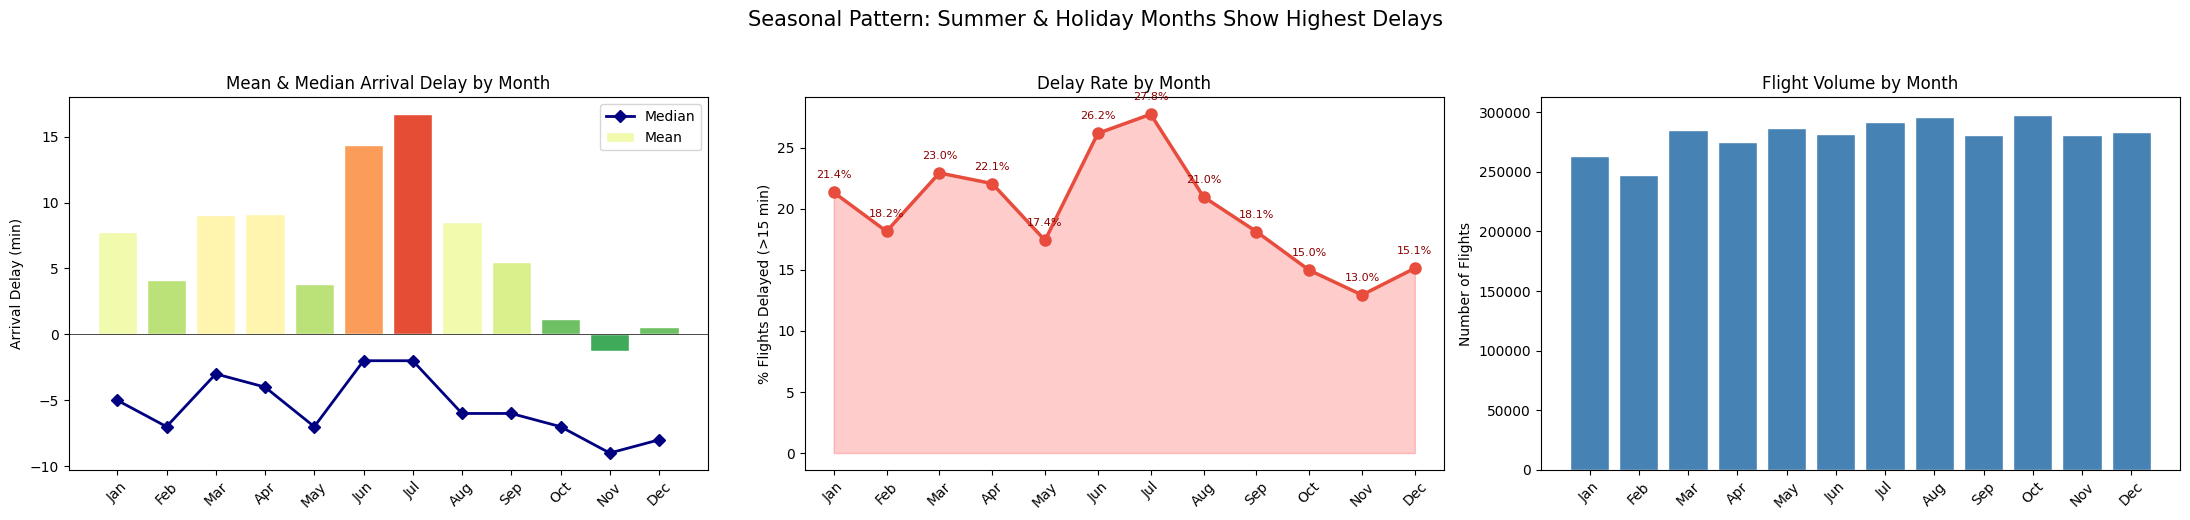


📊 Monthly Delay Summary:
Month  Mean Delay  Median Delay  % Delayed  Flights
  Jan    7.751116          -5.0  21.358814   263259
  Feb    4.123760          -7.0  18.165737   247042
  Mar    9.031598          -3.0  22.951509   285271
  Apr    9.097799          -4.0  22.081924   274890
  May    3.787681          -7.0  17.428292   287171
  Jun   14.368403          -2.0  26.196738   282142
  Jul   16.691476          -2.0  27.760375   292107
  Aug    8.486818          -6.0  20.995955   296419
  Sep    5.473835          -6.0  18.148432   280735
  Oct    1.176446          -7.0  14.987082   297643
  Nov   -1.286914          -9.0  12.952514   280903
  Dec    0.581737          -8.0  15.144236   283494


In [0]:
month_names_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                   7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = pdf.groupby('month').agg(
    mean_delay   = (arr_delay_col, 'mean'),
    median_delay = (arr_delay_col, 'median'),
    pct_delayed  = (arr_delay_col, lambda x: (x > 15).mean() * 100),
    flight_count = (arr_delay_col, 'count')
).reset_index()
monthly['month_label'] = monthly['month'].map(month_names_map)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# --- Mean & Median Delay ---
ax = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, 12))
month_colors = [colors[int(((v - monthly['mean_delay'].min()) /
                (monthly['mean_delay'].max() - monthly['mean_delay'].min())) * 11)]
                for v in monthly['mean_delay']]
ax.bar(monthly['month'], monthly['mean_delay'], color=month_colors, edgecolor='white', label='Mean')
ax.plot(monthly['month'], monthly['median_delay'], 'D-', color='navy', linewidth=2,
        markersize=6, label='Median')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names_map[m] for m in range(1, 13)], rotation=45)
ax.set_ylabel("Arrival Delay (min)")
ax.set_title("Mean & Median Arrival Delay by Month")
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()

# --- % Delayed ---
ax = axes[1]
ax.fill_between(monthly['month'], monthly['pct_delayed'], alpha=0.2, color='red')
ax.plot(monthly['month'], monthly['pct_delayed'], 'o-', color='#e74c3c',
        linewidth=2.5, markersize=8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names_map[m] for m in range(1, 13)], rotation=45)
ax.set_ylabel("% Flights Delayed (>15 min)")
ax.set_title("Delay Rate by Month")
for _, row in monthly.iterrows():
    ax.annotate(f"{row['pct_delayed']:.1f}%",
                (row['month'], row['pct_delayed']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8, color='darkred')

# --- Flight Volume ---
ax = axes[2]
ax.bar(monthly['month'], monthly['flight_count'], color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names_map[m] for m in range(1, 13)], rotation=45)
ax.set_ylabel("Number of Flights")
ax.set_title("Flight Volume by Month")

plt.suptitle("Seasonal Pattern: Summer & Holiday Months Show Highest Delays",
             fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# Print table
print("\n📊 Monthly Delay Summary:")
print(monthly[['month_label', 'mean_delay', 'median_delay', 'pct_delayed', 'flight_count']]
      .rename(columns={'month_label':'Month', 'mean_delay':'Mean Delay',
                        'median_delay':'Median Delay', 'pct_delayed':'% Delayed',
                        'flight_count':'Flights'})
      .to_string(index=False))

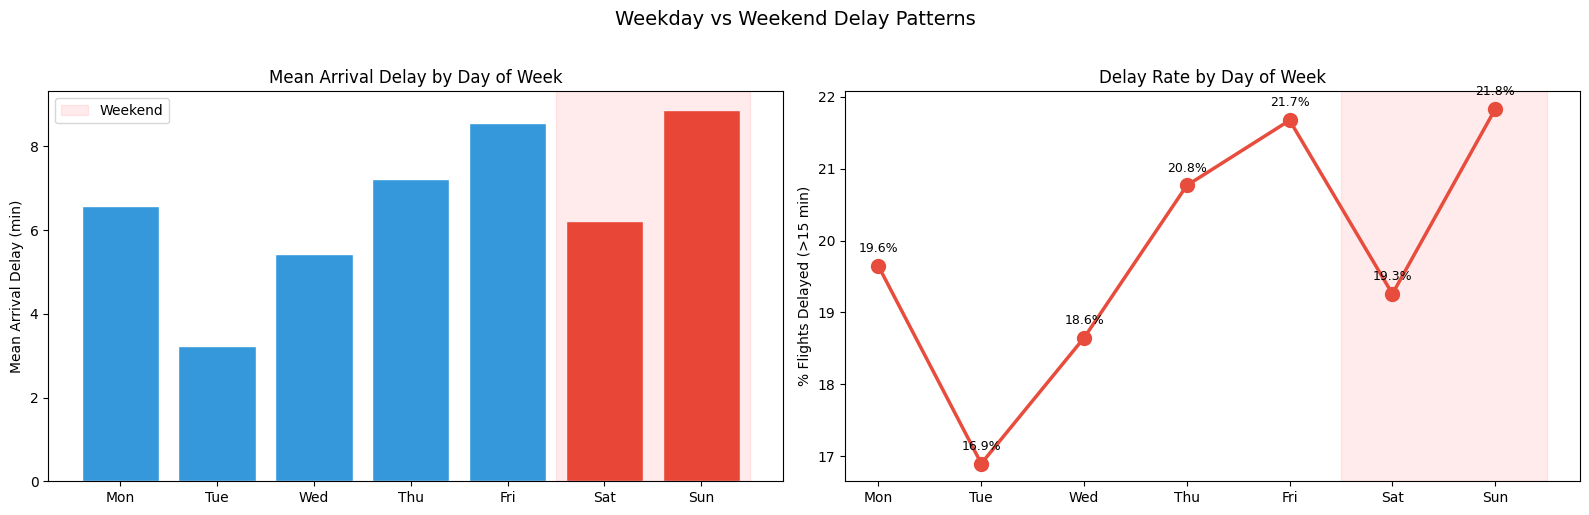


📊 Day of Week Summary:
day_label  mean_delay  pct_delayed  flight_count
      Mon    6.574677    19.642424        498299
      Tue    3.233342    16.897899        468360
      Wed    5.429600    18.646952        475992
      Thu    7.223833    20.766316        499063
      Fri    8.569720    21.671632        501785
      Sat    6.230023    19.257751        435487
      Sun    8.873466    21.828527        492090


In [0]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_stats = pdf.groupby('day_of_week').agg(
    mean_delay  = (arr_delay_col, 'mean'),
    pct_delayed = (arr_delay_col, lambda x: (x > 15).mean() * 100),
    flight_count = (arr_delay_col, 'count')
).reset_index()
dow_stats['day_label'] = dow_stats['day_of_week'].map(dict(enumerate(day_short)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean delay
ax = axes[0]
bar_colors = ['#e74c3c' if d >= 5 else '#3498db' for d in dow_stats['day_of_week']]
ax.bar(dow_stats['day_of_week'], dow_stats['mean_delay'], color=bar_colors, edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(day_short)
ax.set_ylabel("Mean Arrival Delay (min)")
ax.set_title("Mean Arrival Delay by Day of Week")
ax.axhline(y=0, color='black', linewidth=0.5)
# Highlight weekend
ax.axvspan(4.5, 6.5, alpha=0.08, color='red', label='Weekend')
ax.legend()

# % Delayed
ax = axes[1]
ax.plot(dow_stats['day_of_week'], dow_stats['pct_delayed'], 'o-', color='#e74c3c',
        linewidth=2.5, markersize=10)
ax.set_xticks(range(7))
ax.set_xticklabels(day_short)
ax.set_ylabel("% Flights Delayed (>15 min)")
ax.set_title("Delay Rate by Day of Week")
ax.axvspan(4.5, 6.5, alpha=0.08, color='red', label='Weekend')
for _, row in dow_stats.iterrows():
    ax.annotate(f"{row['pct_delayed']:.1f}%",
                (row['day_of_week'], row['pct_delayed']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9)

plt.suptitle("Weekday vs Weekend Delay Patterns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Day of Week Summary:")
print(dow_stats[['day_label','mean_delay','pct_delayed','flight_count']]
      .to_string(index=False))

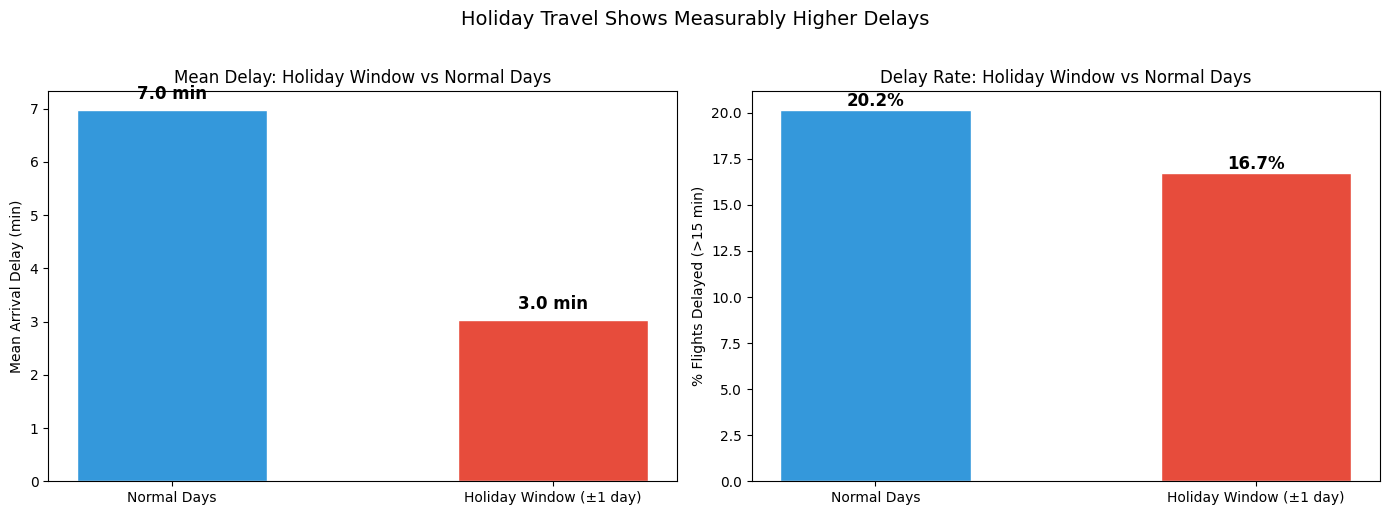


📊 Holiday vs Normal Comparison:
                  label  mean_delay  median_delay  pct_delayed  flight_count
            Normal Days    6.978193          -6.0    20.158272       3076092
Holiday Window (±1 day)    3.031849          -8.0    16.731416        294984


In [0]:
holiday_comp = pdf.groupby('is_holiday_window').agg(
    mean_delay  = (arr_delay_col, 'mean'),
    median_delay = (arr_delay_col, 'median'),
    pct_delayed = (arr_delay_col, lambda x: (x > 15).mean() * 100),
    flight_count = (arr_delay_col, 'count')
).reset_index()
holiday_comp['label'] = holiday_comp['is_holiday_window'].map({0: 'Normal Days', 1: 'Holiday Window (±1 day)'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean delay comparison
ax = axes[0]
colors = ['#3498db', '#e74c3c']
ax.bar(holiday_comp['label'], holiday_comp['mean_delay'], color=colors, edgecolor='white', width=0.5)
ax.set_ylabel("Mean Arrival Delay (min)")
ax.set_title("Mean Delay: Holiday Window vs Normal Days")
for i, row in holiday_comp.iterrows():
    ax.text(i, row['mean_delay'] + 0.2, f"{row['mean_delay']:.1f} min",
            ha='center', fontsize=12, fontweight='bold')

# % Delayed comparison
ax = axes[1]
ax.bar(holiday_comp['label'], holiday_comp['pct_delayed'], color=colors, edgecolor='white', width=0.5)
ax.set_ylabel("% Flights Delayed (>15 min)")
ax.set_title("Delay Rate: Holiday Window vs Normal Days")
for i, row in holiday_comp.iterrows():
    ax.text(i, row['pct_delayed'] + 0.2, f"{row['pct_delayed']:.1f}%",
            ha='center', fontsize=12, fontweight='bold')

plt.suptitle("Holiday Travel Shows Measurably Higher Delays", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Holiday vs Normal Comparison:")
print(holiday_comp[['label','mean_delay','median_delay','pct_delayed','flight_count']]
      .to_string(index=False))


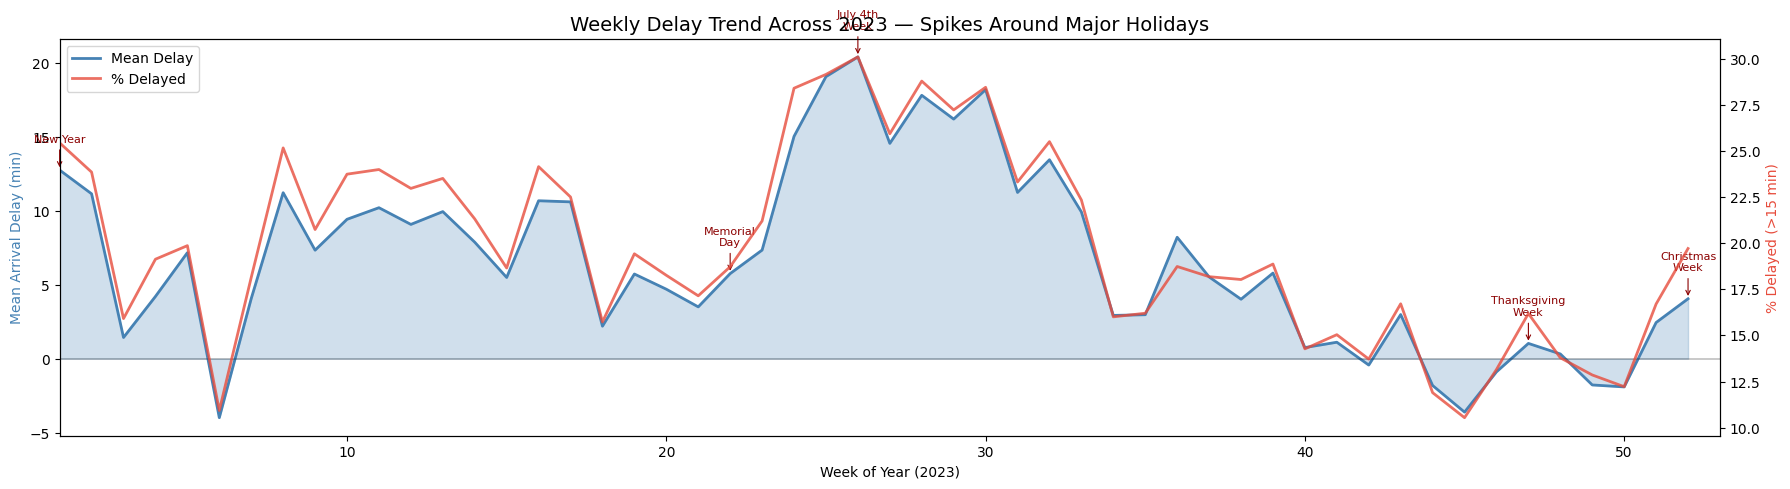

In [0]:
weekly = pdf.groupby('week_of_year').agg(
    mean_delay  = (arr_delay_col, 'mean'),
    pct_delayed = (arr_delay_col, lambda x: (x > 15).mean() * 100),
    flight_count = (arr_delay_col, 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(18, 5))

ax1.fill_between(weekly['week_of_year'], weekly['mean_delay'], alpha=0.25, color='steelblue')
ax1.plot(weekly['week_of_year'], weekly['mean_delay'], '-', color='steelblue',
         linewidth=2, label='Mean Delay')
ax1.set_xlabel("Week of Year (2023)")
ax1.set_ylabel("Mean Arrival Delay (min)", color='steelblue')
ax1.axhline(y=0, color='black', linewidth=0.3)

ax2 = ax1.twinx()
ax2.plot(weekly['week_of_year'], weekly['pct_delayed'], '-', color='#e74c3c',
         linewidth=2, alpha=0.8, label='% Delayed')
ax2.set_ylabel("% Delayed (>15 min)", color='#e74c3c')

# Annotate key periods
annotations = {26: 'July 4th\nWeek', 47: 'Thanksgiving\nWeek', 52: 'Christmas\nWeek',
               1: 'New Year', 22: 'Memorial\nDay'}
for wk, label in annotations.items():
    if wk in weekly['week_of_year'].values:
        val = weekly.loc[weekly['week_of_year'] == wk, 'mean_delay'].values[0]
        ax1.annotate(label, (wk, val), textcoords="offset points", xytext=(0, 20),
                     ha='center', fontsize=8, color='darkred',
                     arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

ax1.set_title("Weekly Delay Trend Across 2023 — Spikes Around Major Holidays", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_xlim(1, 53)
plt.tight_layout()
plt.show()

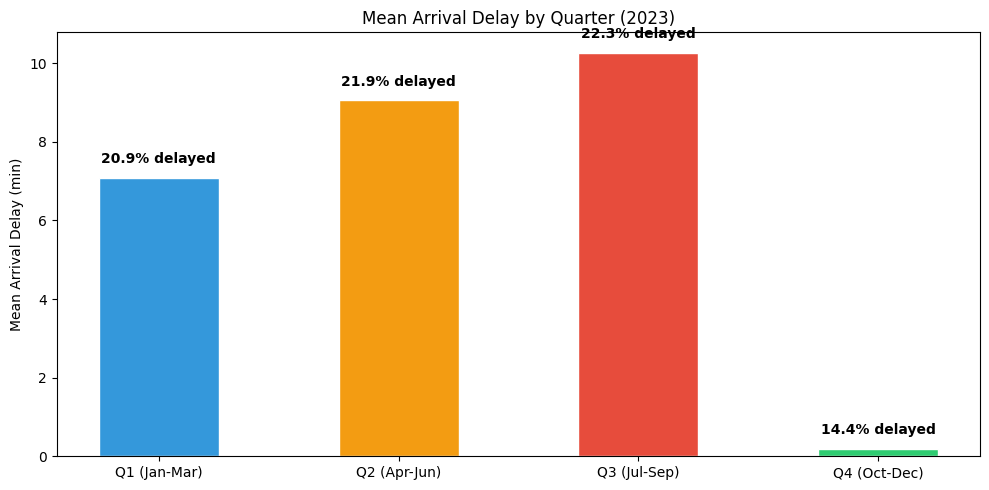


📊 Quarterly Summary:
       label  mean_delay  pct_delayed  flight_count
Q1 (Jan-Mar)    7.083892    20.938394        795572
Q2 (Apr-Jun)    9.052960    21.874123        844203
Q3 (Jul-Sep)   10.270848    22.349444        869261
Q4 (Oct-Dec)    0.178161    14.375783        862040


In [0]:
quarter_stats = pdf.groupby('quarter').agg(
    mean_delay  = (arr_delay_col, 'mean'),
    pct_delayed = (arr_delay_col, lambda x: (x > 15).mean() * 100),
    flight_count = (arr_delay_col, 'count')
).reset_index()
quarter_stats['label'] = quarter_stats['quarter'].map({1:'Q1 (Jan-Mar)', 2:'Q2 (Apr-Jun)',
                                                        3:'Q3 (Jul-Sep)', 4:'Q4 (Oct-Dec)'})

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']
bars = ax.bar(quarter_stats['label'], quarter_stats['mean_delay'],
              color=colors, edgecolor='white', width=0.5)
ax.set_ylabel("Mean Arrival Delay (min)")
ax.set_title("Mean Arrival Delay by Quarter (2023)")
ax.axhline(y=0, color='black', linewidth=0.5)
for bar, pct in zip(bars, quarter_stats['pct_delayed']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}% delayed', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Quarterly Summary:")
print(quarter_stats[['label','mean_delay','pct_delayed','flight_count']].to_string(index=False))


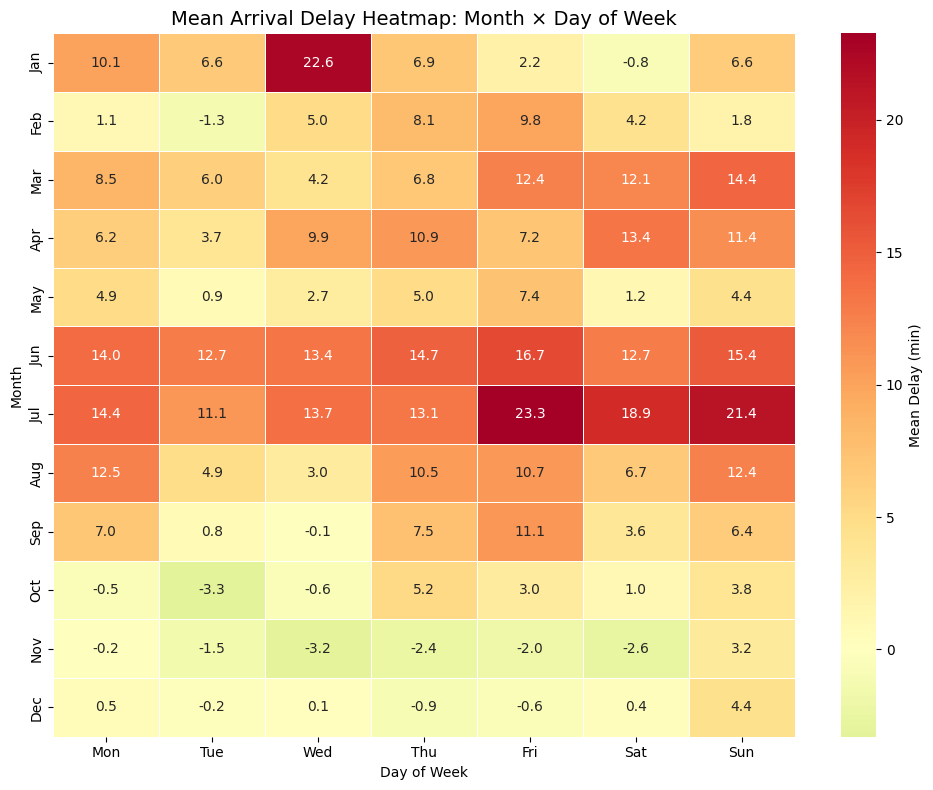

In [0]:
heatmap_data = pdf.groupby(['month', 'day_of_week'])[arr_delay_col].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='month', columns='day_of_week', values=arr_delay_col)
heatmap_pivot.index = [month_names_map[m] for m in heatmap_pivot.index]
heatmap_pivot.columns = day_short

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Delay (min)'})
ax.set_title("Mean Arrival Delay Heatmap: Month × Day of Week", fontsize=14)
ax.set_ylabel("Month")
ax.set_xlabel("Day of Week")
plt.tight_layout()
plt.show()

In [0]:
# COMMAND ----------

# MAGIC %md
# MAGIC ## 7. Weather × Flight Delay Analysis
# MAGIC
# MAGIC We join the flights table with hourly weather observations on **`FlightDate = time`** and **`Dep_Airport = airport_id`**, then analyze how each weather variable relates to delay severity.

# COMMAND ----------

# ──────────────────────────────────────────────
# 7.0  Join Flights with Weather in Spark
# ──────────────────────────────────────────────
flights_with_weather_df = flights_df.join(
    weather_df,
    on=(flights_df["FlightDate"] == weather_df["time"]) &
       (flights_df["Dep_Airport"] == weather_df["airport_id"]),
    how="left"
)

print(f"✅ Join complete")
print(f"   Flights (original):       {flights_df.count():>10,}")
print(f"   Flights+Weather (joined): {flights_with_weather_df.count():>10,}")
print(f"   Columns after join:       {len(flights_with_weather_df.columns)}")

✅ Join complete
   Flights (original):        6,743,404
   Flights+Weather (joined):  6,743,404
   Columns after join:       34


In [0]:
total = flights_with_weather_df.count()
weather_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres']

print("Weather Column Match Rate:")
print("-" * 45)
for wc in weather_cols:
    non_null = flights_with_weather_df.where(F.col(wc).isNotNull()).count()
    print(f"  {wc:>12s}:  {non_null:>10,} / {total:,}  ({non_null/total*100:.1f}%)")

Weather Column Match Rate:
---------------------------------------------
          tavg:   6,743,404 / 6,743,404  (100.0%)
          tmin:   6,743,404 / 6,743,404  (100.0%)
          tmax:   6,743,404 / 6,743,404  (100.0%)
          prcp:   6,743,404 / 6,743,404  (100.0%)
          snow:   6,743,404 / 6,743,404  (100.0%)
          wdir:   6,743,404 / 6,743,404  (100.0%)
          wspd:   6,743,404 / 6,743,404  (100.0%)
          pres:   6,743,404 / 6,743,404  (100.0%)


In [0]:
WEATHER_SAMPLE = 0.5  # 50% sample

fw_sampled = flights_with_weather_df.sample(False, WEATHER_SAMPLE, seed=42)
fw_pd = fw_sampled.toPandas()

# Standardize column names
fw_pd.columns = fw_pd.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('.', '_', regex=False)

print(f"Sampled {len(fw_pd):,} rows for weather analysis")
print(f"Columns: {fw_pd.columns.tolist()}")

Sampled 3,371,076 rows for weather analysis
Columns: ['flightdate', 'day_of_week', 'airline', 'tail_number', 'dep_airport', 'dep_cityname', 'deptime_label', 'dep_delay', 'dep_delay_tag', 'dep_delay_type', 'arr_airport', 'arr_cityname', 'arr_delay', 'arr_delay_type', 'flight_duration', 'distance_type', 'delay_carrier', 'delay_weather', 'delay_nas', 'delay_security', 'delay_lastaircraft', 'manufacturer', 'model', 'aicraft_age', 'time', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'airport_id']


In [0]:
fw_arr_delay_col = None
for c in fw_pd.columns:
    if 'arr' in c and 'del' in c and 'group' not in c:
        fw_arr_delay_col = c
        break
if fw_arr_delay_col is None:
    for c in fw_pd.columns:
        if 'arr' in c and 'delay' in c:
            fw_arr_delay_col = c
            break

fw_dep_delay_col = None
for c in fw_pd.columns:
    if 'dep' in c and 'del' in c and 'group' not in c:
        fw_dep_delay_col = c
        break

print(f"Arrival delay column:   {fw_arr_delay_col}")
print(f"Departure delay column: {fw_dep_delay_col}")

# Create binary delayed flag
fw_pd['is_delayed'] = (fw_pd[fw_arr_delay_col] > 15).astype(int)
print(f"\nDelay rate in weather-joined data: {fw_pd['is_delayed'].mean()*100:.1f}%")

# Ensure weather cols are numeric
for wc in weather_cols:
    wc_lower = wc.lower()
    if wc_lower in fw_pd.columns:
        fw_pd[wc_lower] = pd.to_numeric(fw_pd[wc_lower], errors='coerce')

Arrival delay column:   arr_delay
Departure delay column: dep_delay

Delay rate in weather-joined data: 19.9%


In [0]:
weather_cols_lower = [c.lower() for c in weather_cols if c.lower() in fw_pd.columns]
print(f"Available weather columns: {weather_cols_lower}\n")

weather_desc = fw_pd[weather_cols_lower].describe().T
weather_desc['missing_%'] = (fw_pd[weather_cols_lower].isnull().sum() / len(fw_pd) * 100).round(2)

weather_labels = {
    'tavg': 'Avg Temp (°C)', 'tmin': 'Min Temp (°C)', 'tmax': 'Max Temp (°C)',
    'prcp': 'Precipitation (mm)', 'snow': 'Snow Depth (mm)', 'wdir': 'Wind Dir (°)',
    'wspd': 'Wind Speed (km/h)', 'pres': 'Pressure (hPa)'
}
weather_desc['description'] = weather_desc.index.map(weather_labels)

print("Weather Variable Statistics (across all flights):")
print(weather_desc.to_string())

Available weather columns: ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres']

Weather Variable Statistics (across all flights):
          count         mean         std    min     25%     50%     75%     max  missing_%         description
tavg  3371076.0    16.816510    9.153629  -39.1    10.4    17.8    23.9    42.2        0.0       Avg Temp (°C)
tmin  3371076.0    11.826022    9.177105  -76.0     5.0    12.8    18.9    36.1        0.0       Min Temp (°C)
tmax  3371076.0    22.173350    9.748287  -35.0    15.6    23.3    29.4    48.9        0.0       Max Temp (°C)
prcp  3371076.0     2.435028    8.228238    0.0     0.0     0.0     0.5   571.5        0.0  Precipitation (mm)
snow  3371076.0     3.202842   30.823114    0.0     0.0     0.0     0.0  1520.0        0.0     Snow Depth (mm)
wdir  3371076.0   188.867693  111.290254    0.0    83.0   198.0   290.0   360.0        0.0        Wind Dir (°)
wspd  3371076.0    12.477195    5.644498    0.0     8.4    11.5    15.5    59.4 

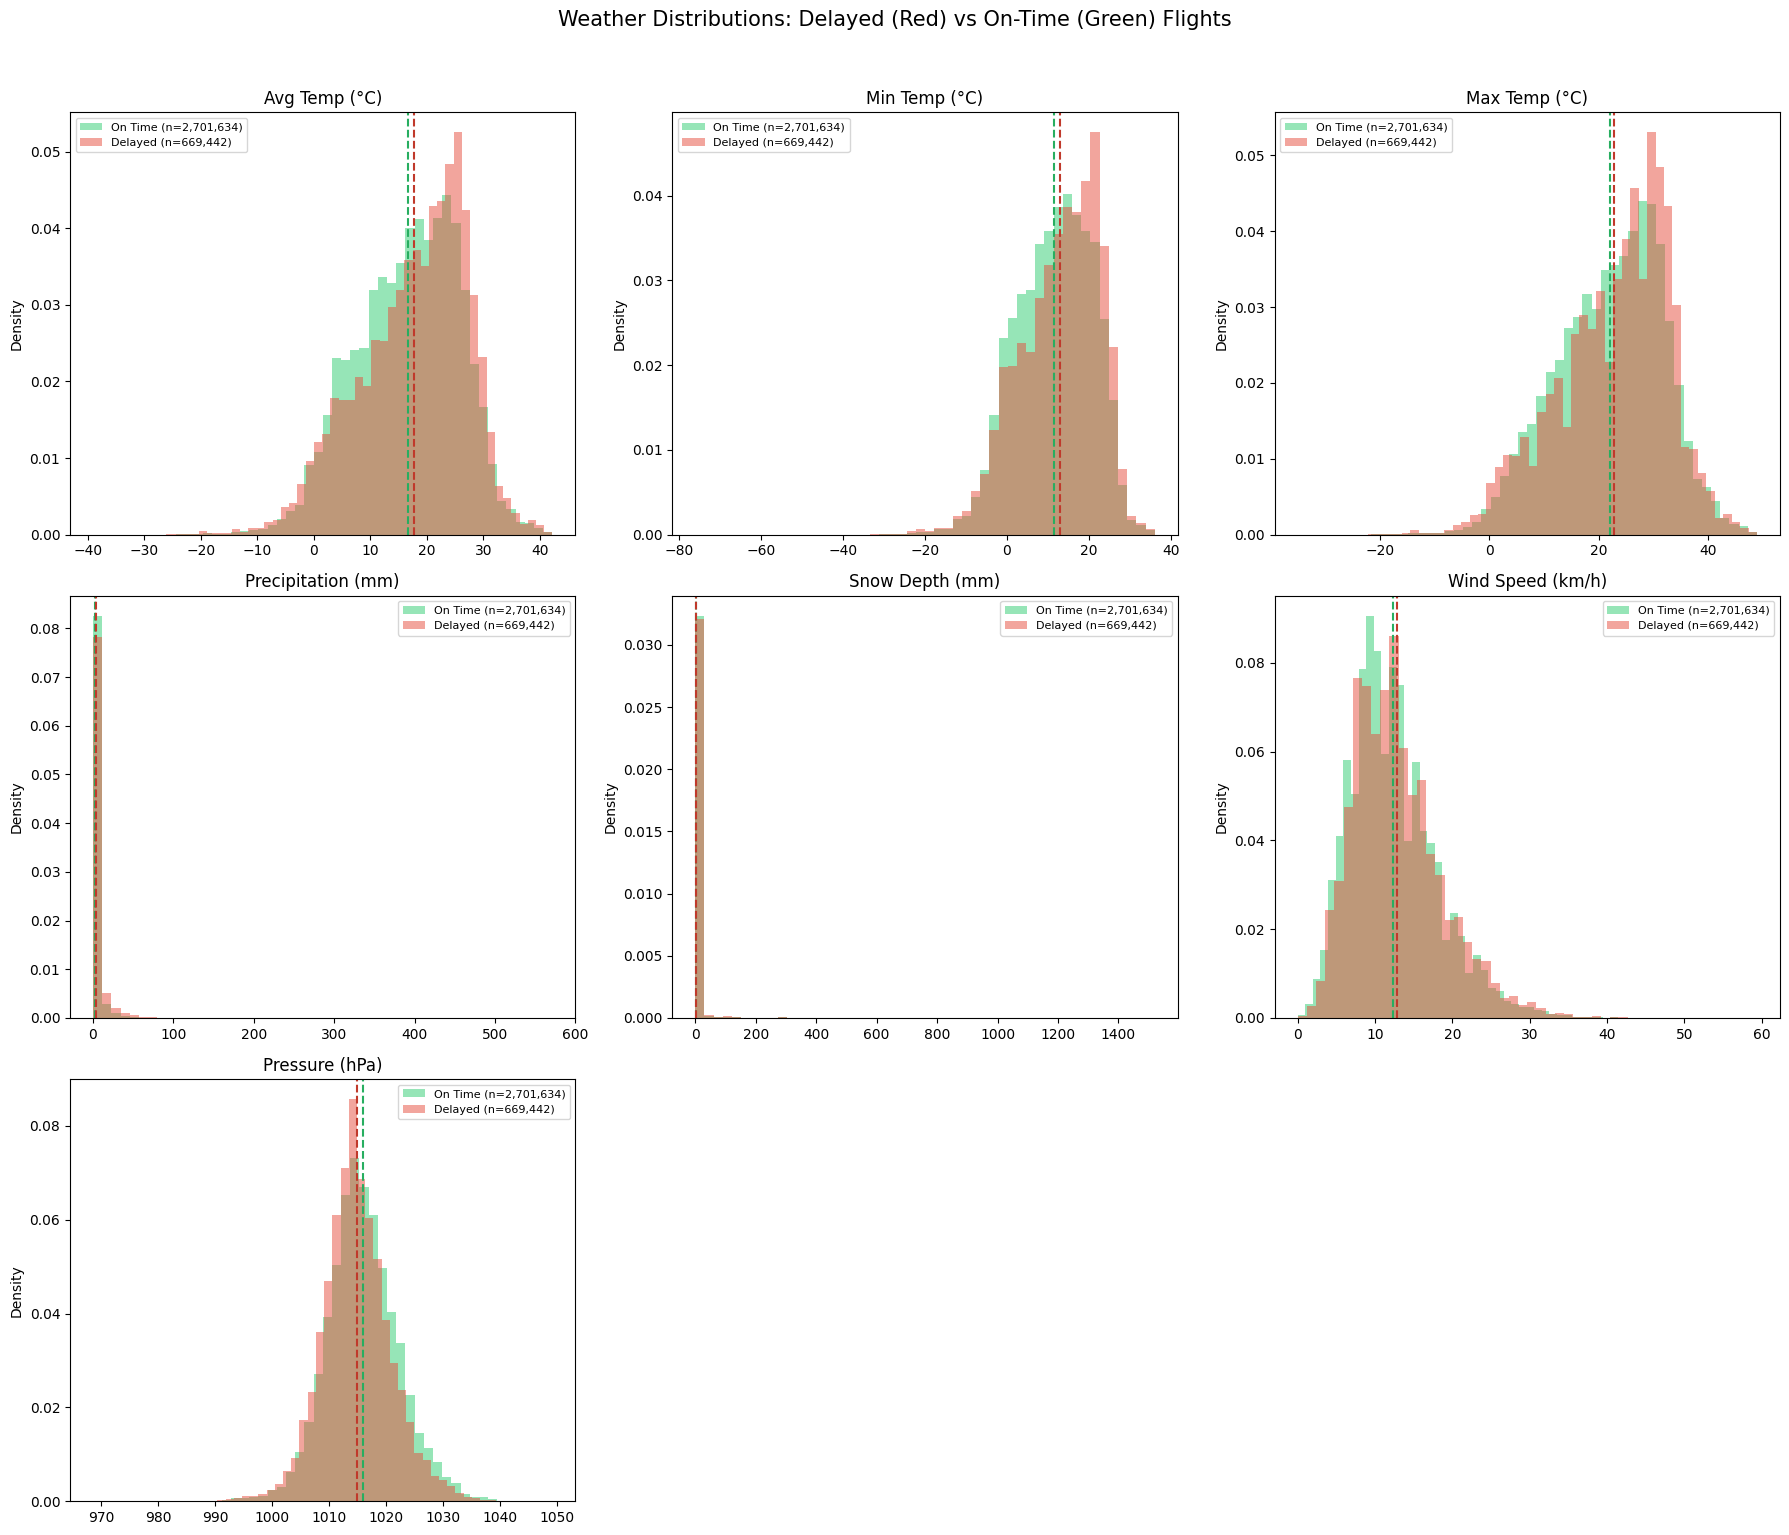

In [0]:
plot_weather = [c for c in weather_cols_lower if c not in ['wdir'] and fw_pd[c].notna().sum() > 1000]

n_cols = 3
n_rows = (len(plot_weather) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, wc in enumerate(plot_weather):
    ax = axes[i]
    data_on = fw_pd.loc[fw_pd['is_delayed'] == 0, wc].dropna()
    data_del = fw_pd.loc[fw_pd['is_delayed'] == 1, wc].dropna()

    ax.hist(data_on, bins=50, alpha=0.5, color='#2ecc71', label=f'On Time (n={len(data_on):,})', density=True)
    ax.hist(data_del, bins=50, alpha=0.5, color='#e74c3c', label=f'Delayed (n={len(data_del):,})', density=True)
    ax.set_title(weather_labels.get(wc, wc), fontsize=12)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # Add vertical mean lines
    ax.axvline(data_on.mean(), color='#27ae60', linestyle='--', linewidth=1.5)
    ax.axvline(data_del.mean(), color='#c0392b', linestyle='--', linewidth=1.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Weather Distributions: Delayed (Red) vs On-Time (Green) Flights",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

📊 Mean Weather Comparison: Delayed vs On-Time Flights
  Weather Variable  On-Time Mean  Delayed Mean  Difference  % Difference
     Avg Temp (°C)         16.60         17.69        1.10           6.6
     Min Temp (°C)         11.57         12.88        1.31          11.4
     Max Temp (°C)         22.01         22.84        0.83           3.8
Precipitation (mm)          2.08          3.85        1.77          84.8
   Snow Depth (mm)          3.02          3.93        0.91          30.0
      Wind Dir (°)        189.22        187.44       -1.78          -0.9
 Wind Speed (km/h)         12.37         12.89        0.52           4.2
    Pressure (hPa)       1015.94       1014.86       -1.08          -0.1


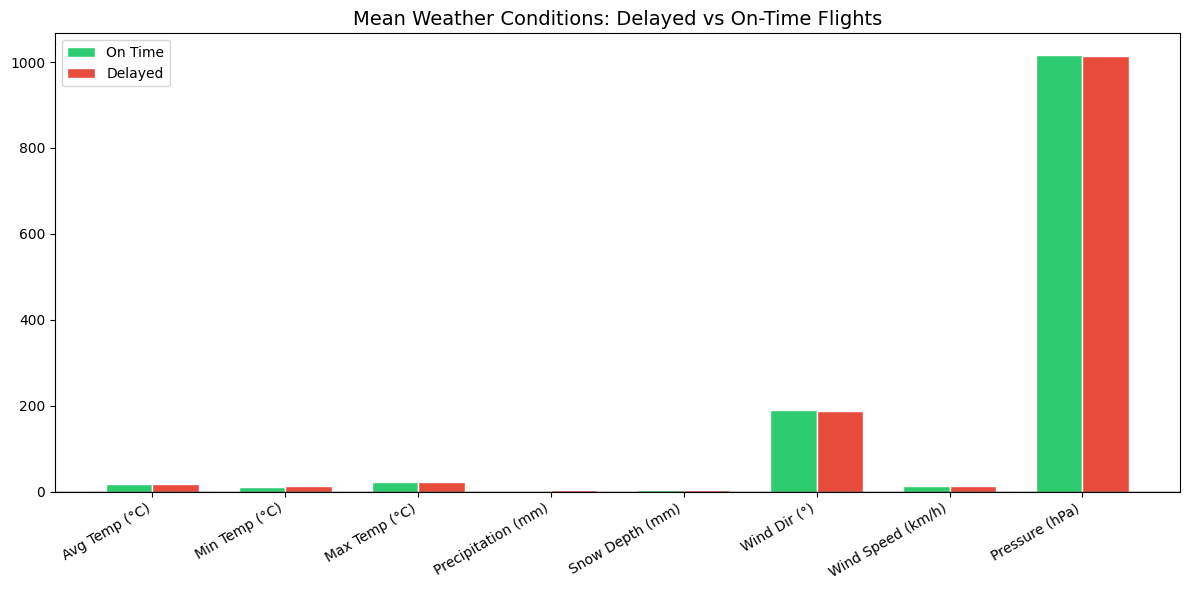

In [0]:
compare_stats = []
for wc in weather_cols_lower:
    on_time_mean = fw_pd.loc[fw_pd['is_delayed'] == 0, wc].mean()
    delayed_mean = fw_pd.loc[fw_pd['is_delayed'] == 1, wc].mean()
    diff = delayed_mean - on_time_mean
    pct_diff = (diff / abs(on_time_mean) * 100) if on_time_mean != 0 else 0
    compare_stats.append({
        'Weather Variable': weather_labels.get(wc, wc),
        'col': wc,
        'On-Time Mean': round(on_time_mean, 2),
        'Delayed Mean': round(delayed_mean, 2),
        'Difference': round(diff, 2),
        '% Difference': round(pct_diff, 1)
    })

compare_df = pd.DataFrame(compare_stats)
print("📊 Mean Weather Comparison: Delayed vs On-Time Flights")
print(compare_df[['Weather Variable', 'On-Time Mean', 'Delayed Mean', 'Difference', '% Difference']].to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(compare_df))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], compare_df['On-Time Mean'], width,
               label='On Time', color='#2ecc71', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], compare_df['Delayed Mean'], width,
               label='Delayed', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(compare_df['Weather Variable'], rotation=30, ha='right')
ax.set_title("Mean Weather Conditions: Delayed vs On-Time Flights", fontsize=14)
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.3)
plt.tight_layout()
plt.show()

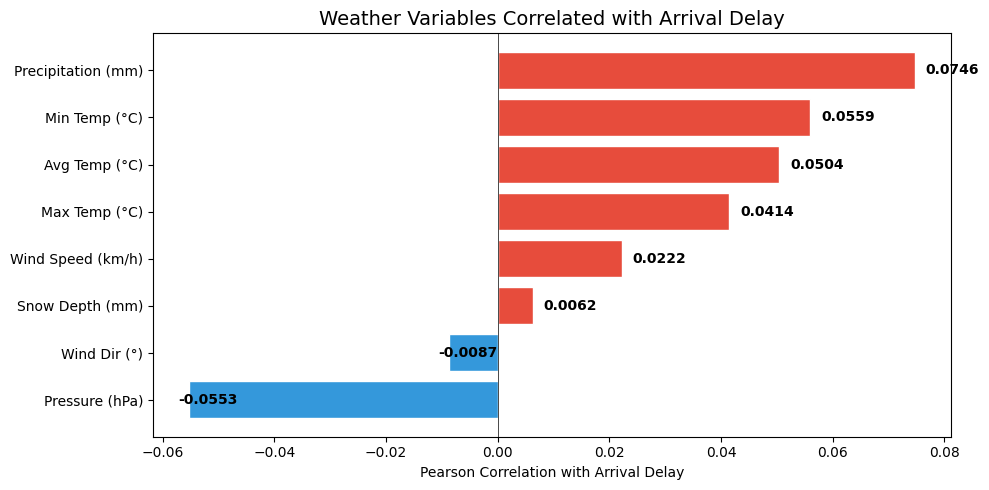


Correlation with Arrival Delay:
Precipitation (mm)    0.074650
Min Temp (°C)         0.055923
Avg Temp (°C)         0.050377
Max Temp (°C)         0.041420
Wind Speed (km/h)     0.022181
Snow Depth (mm)       0.006240
Wind Dir (°)         -0.008670
Pressure (hPa)       -0.055273


In [0]:
weather_delay_corr = fw_pd[weather_cols_lower + [fw_arr_delay_col]].corr()[fw_arr_delay_col].drop(fw_arr_delay_col)
weather_delay_corr = weather_delay_corr.sort_values(ascending=False)
weather_delay_corr.index = weather_delay_corr.index.map(lambda x: weather_labels.get(x, x))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in weather_delay_corr.values]
bars = ax.barh(weather_delay_corr.index, weather_delay_corr.values, color=colors, edgecolor='white')
ax.set_xlabel("Pearson Correlation with Arrival Delay")
ax.set_title("Weather Variables Correlated with Arrival Delay", fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()

for bar, val in zip(bars, weather_delay_corr.values):
    ax.text(val + 0.002 * np.sign(val), bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCorrelation with Arrival Delay:")
print(weather_delay_corr.to_string())

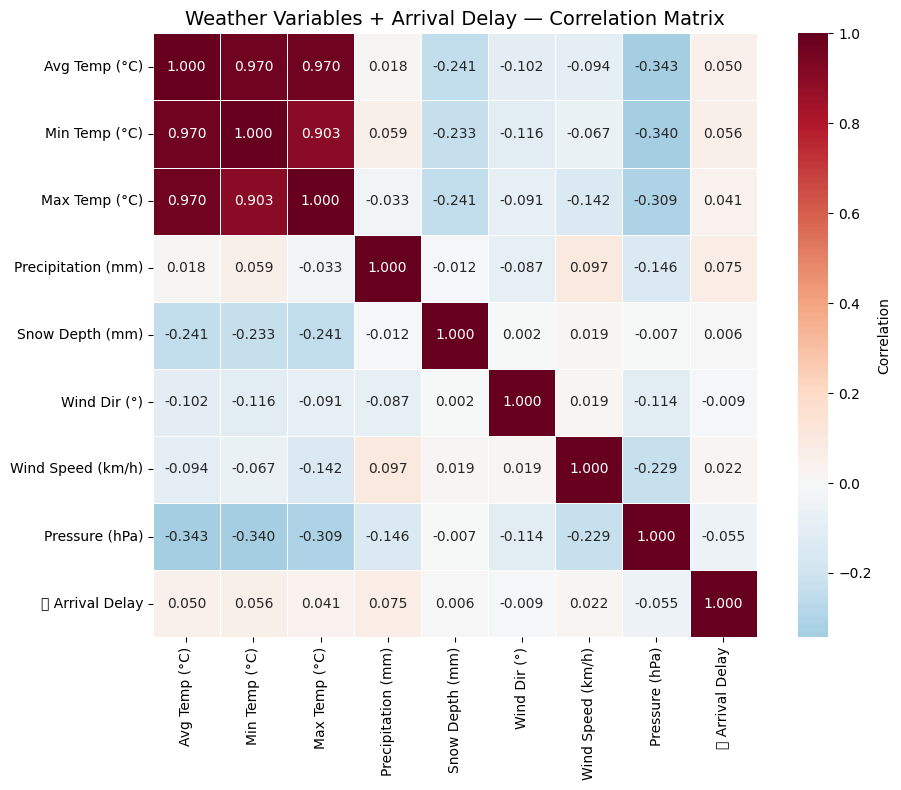

In [0]:
weather_plus_delay = weather_cols_lower + [fw_arr_delay_col]
corr_mtx = fw_pd[weather_plus_delay].corr()

rename_map = {c: weather_labels.get(c, c) for c in corr_mtx.columns}
rename_map[fw_arr_delay_col] = '⭐ Arrival Delay'
corr_mtx = corr_mtx.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mtx, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, square=True, cbar_kws={'label': 'Correlation'})
ax.set_title("Weather Variables + Arrival Delay — Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

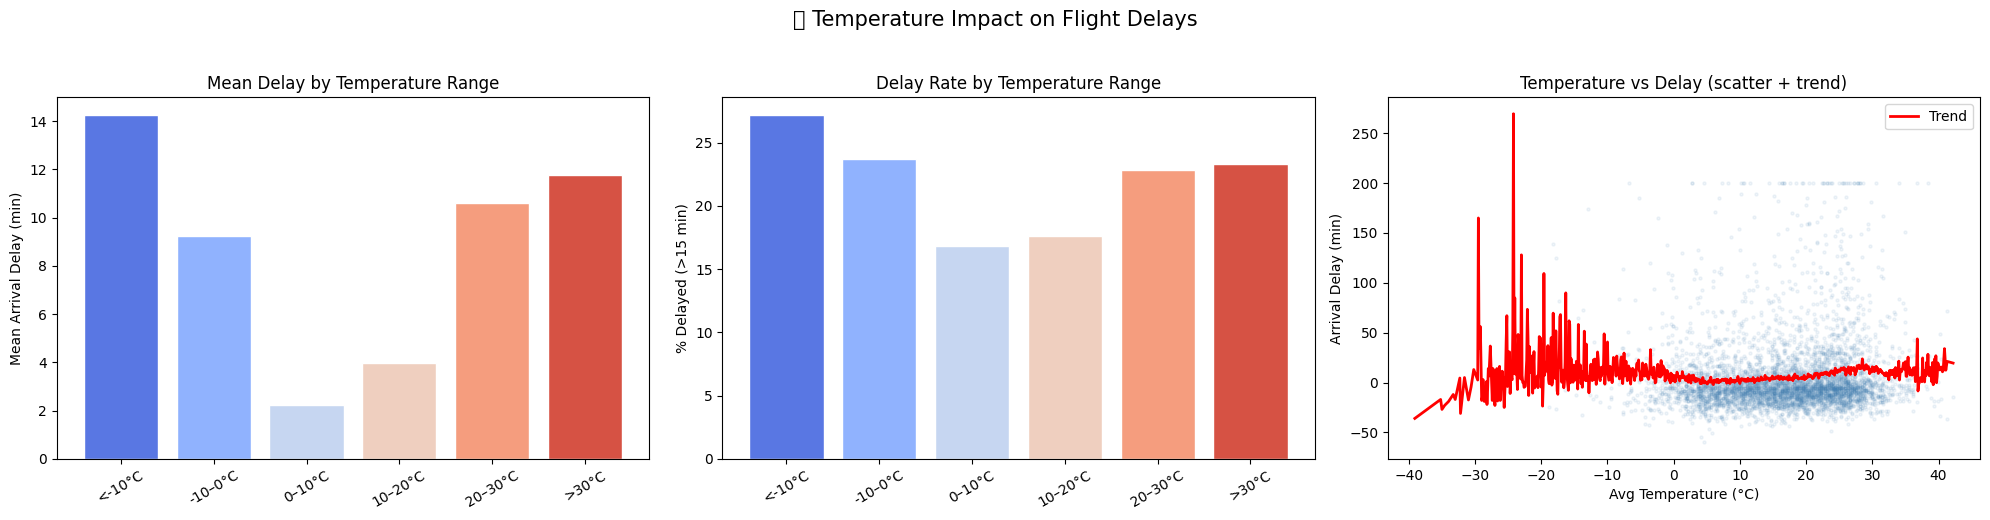


Temperature Bin Statistics:
temp_bin  mean_delay  pct_delayed   count
  <-10°C   14.275049    27.217384   11827
 -10–0°C    9.243224    23.707986  118323
  0–10°C    2.247491    16.793891  672959
 10–20°C    3.976708    17.615629 1182660
 20–30°C   10.606857    22.811616 1222877
   >30°C   11.767935    23.313650  162407


In [0]:
if 'tavg' in fw_pd.columns:
    temp_data = fw_pd[['tavg', fw_arr_delay_col, 'is_delayed']].dropna()

    # Bin temperature
    temp_data['temp_bin'] = pd.cut(temp_data['tavg'],
                                    bins=[-30, -10, 0, 10, 20, 30, 45],
                                    labels=['<-10°C', '-10–0°C', '0–10°C', '10–20°C', '20–30°C', '>30°C'])

    temp_stats = temp_data.groupby('temp_bin', observed=True).agg(
        mean_delay  = (fw_arr_delay_col, 'mean'),
        pct_delayed = ('is_delayed', 'mean'),
        count       = (fw_arr_delay_col, 'count')
    ).reset_index()
    temp_stats['pct_delayed'] *= 100

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Bar: mean delay
    cmap_temp = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(temp_stats)))
    axes[0].bar(temp_stats['temp_bin'].astype(str), temp_stats['mean_delay'],
                color=cmap_temp, edgecolor='white')
    axes[0].set_ylabel("Mean Arrival Delay (min)")
    axes[0].set_title("Mean Delay by Temperature Range")
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

    # % delayed
    axes[1].bar(temp_stats['temp_bin'].astype(str), temp_stats['pct_delayed'],
                color=cmap_temp, edgecolor='white')
    axes[1].set_ylabel("% Delayed (>15 min)")
    axes[1].set_title("Delay Rate by Temperature Range")
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

    # Scatter (sampled)
    scatter_sample = temp_data.sample(min(5000, len(temp_data)), random_state=42)
    axes[2].scatter(scatter_sample['tavg'], scatter_sample[fw_arr_delay_col].clip(-60, 200),
                    alpha=0.08, s=5, c='steelblue')
    # Rolling mean trend
    temp_sorted = temp_data.sort_values('tavg')
    rolling = temp_sorted.groupby(temp_sorted['tavg'].round(1))[fw_arr_delay_col].mean()
    axes[2].plot(rolling.index, rolling.values, color='red', linewidth=2, label='Trend')
    axes[2].set_xlabel("Avg Temperature (°C)")
    axes[2].set_ylabel("Arrival Delay (min)")
    axes[2].set_title("Temperature vs Delay (scatter + trend)")
    axes[2].legend()

    plt.suptitle("🌡️ Temperature Impact on Flight Delays", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    print("\nTemperature Bin Statistics:")
    print(temp_stats.to_string(index=False))

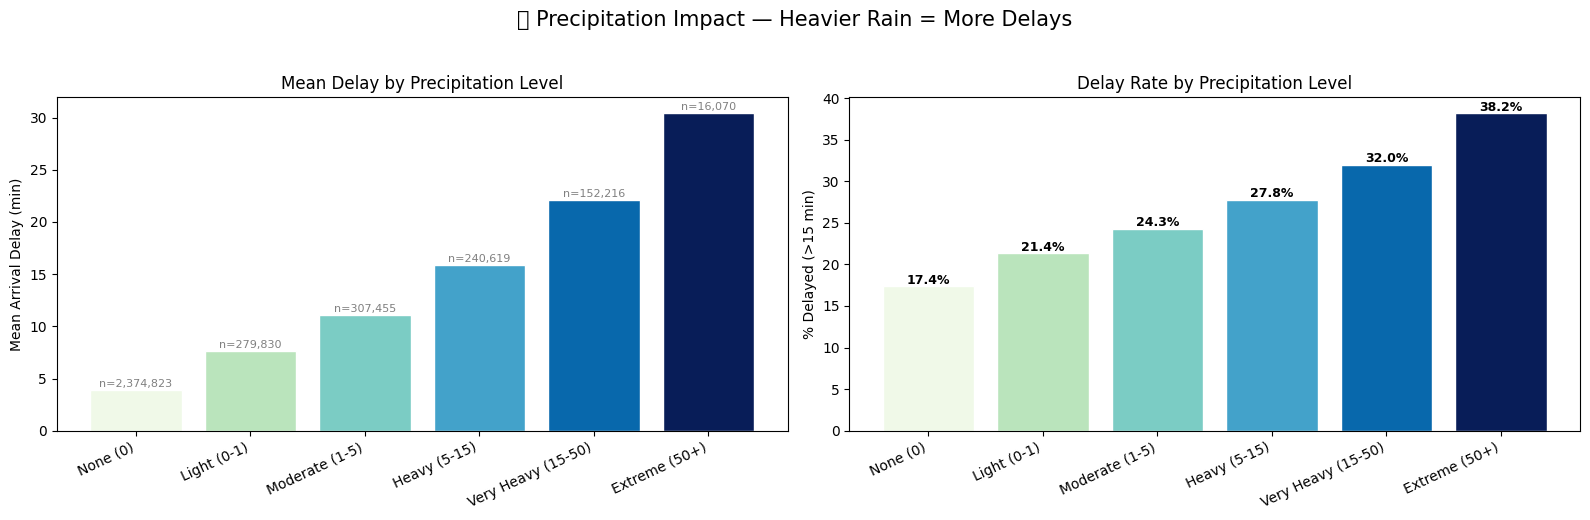


Precipitation Bin Statistics:
          prcp_bin  mean_delay  pct_delayed   count
          None (0)    3.858750    17.401928 2374823
       Light (0-1)    7.593978    21.368688  279830
    Moderate (1-5)   11.051575    24.303719  307455
      Heavy (5-15)   15.888404    27.765887  240619
Very Heavy (15-50)   22.083992    31.995979  152216
     Extreme (50+)   30.411139    38.176727   16070


In [0]:
if 'prcp' in fw_pd.columns:
    prcp_data = fw_pd[['prcp', fw_arr_delay_col, 'is_delayed']].dropna()
    prcp_data = prcp_data[prcp_data['prcp'] >= 0]  # valid only

    # Bin precipitation
    prcp_data['prcp_bin'] = pd.cut(prcp_data['prcp'],
                                    bins=[-0.1, 0, 1, 5, 15, 50, 500],
                                    labels=['None (0)', 'Light (0-1)', 'Moderate (1-5)',
                                            'Heavy (5-15)', 'Very Heavy (15-50)', 'Extreme (50+)'])

    prcp_stats = prcp_data.groupby('prcp_bin', observed=True).agg(
        mean_delay  = (fw_arr_delay_col, 'mean'),
        pct_delayed = ('is_delayed', 'mean'),
        count       = (fw_arr_delay_col, 'count')
    ).reset_index()
    prcp_stats['pct_delayed'] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Mean delay
    rain_colors = ['#f0f9e8', '#bae4bc', '#7bccc4', '#43a2ca', '#0868ac', '#081d58']
    axes[0].bar(prcp_stats['prcp_bin'].astype(str), prcp_stats['mean_delay'],
                color=rain_colors[:len(prcp_stats)], edgecolor='white')
    axes[0].set_ylabel("Mean Arrival Delay (min)")
    axes[0].set_title("Mean Delay by Precipitation Level")
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha='right')
    for j, row in prcp_stats.iterrows():
        axes[0].text(j, row['mean_delay'] + 0.3, f"n={row['count']:,}",
                     ha='center', fontsize=8, color='gray')

    # % delayed
    axes[1].bar(prcp_stats['prcp_bin'].astype(str), prcp_stats['pct_delayed'],
                color=rain_colors[:len(prcp_stats)], edgecolor='white')
    axes[1].set_ylabel("% Delayed (>15 min)")
    axes[1].set_title("Delay Rate by Precipitation Level")
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right')
    for j, row in prcp_stats.iterrows():
        axes[1].text(j, row['pct_delayed'] + 0.3, f"{row['pct_delayed']:.1f}%",
                     ha='center', fontsize=9, fontweight='bold')

    plt.suptitle("🌧️ Precipitation Impact — Heavier Rain = More Delays", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    print("\nPrecipitation Bin Statistics:")
    print(prcp_stats.to_string(index=False))

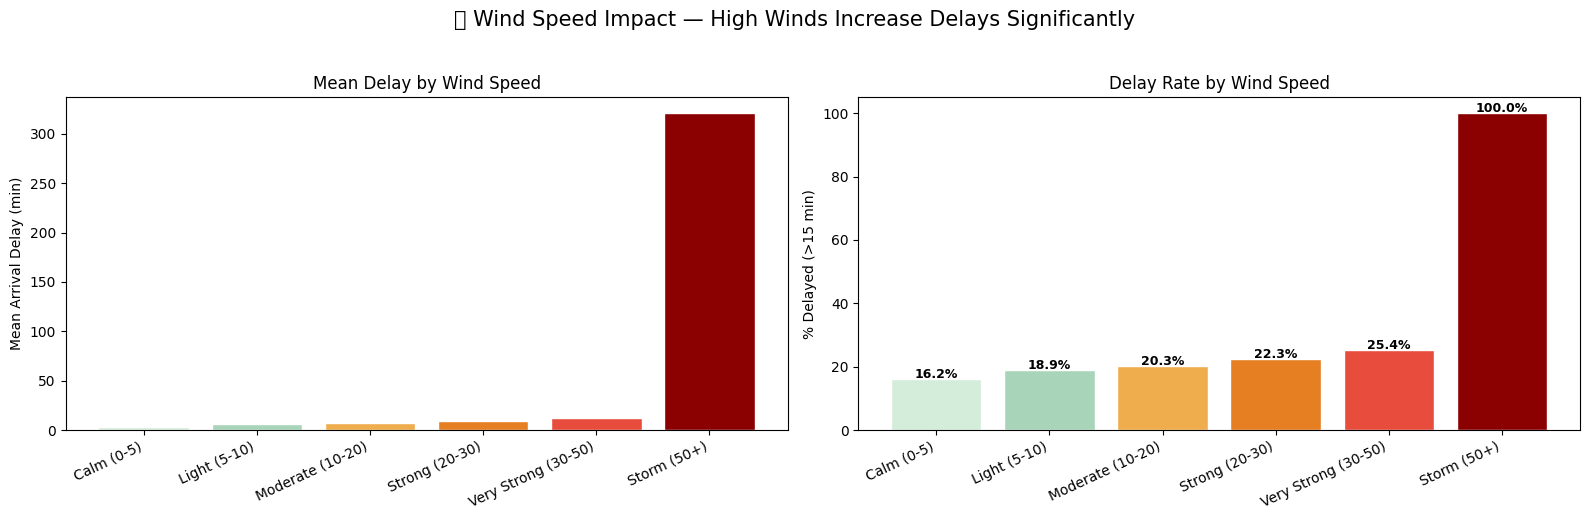


Wind Speed Bin Statistics:
           wind_bin  mean_delay  pct_delayed   count
         Calm (0-5)    3.492239    16.162393  213112
       Light (5-10)    5.869585    18.933657 1033720
   Moderate (10-20)    6.977268    20.315746 1782253
     Strong (20-30)    8.792277    22.328053  314443
Very Strong (30-50)   12.630050    25.371184   27547
        Storm (50+)  321.000000   100.000000       1


In [0]:
if 'wspd' in fw_pd.columns:
    wind_data = fw_pd[['wspd', fw_arr_delay_col, 'is_delayed']].dropna()

    wind_data['wind_bin'] = pd.cut(wind_data['wspd'],
                                    bins=[-0.1, 5, 10, 20, 30, 50, 200],
                                    labels=['Calm (0-5)', 'Light (5-10)', 'Moderate (10-20)',
                                            'Strong (20-30)', 'Very Strong (30-50)', 'Storm (50+)'])

    wind_stats = wind_data.groupby('wind_bin', observed=True).agg(
        mean_delay  = (fw_arr_delay_col, 'mean'),
        pct_delayed = ('is_delayed', 'mean'),
        count       = (fw_arr_delay_col, 'count')
    ).reset_index()
    wind_stats['pct_delayed'] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    wind_colors = ['#d4edda', '#a8d5ba', '#f0ad4e', '#e67e22', '#e74c3c', '#8b0000']

    axes[0].bar(wind_stats['wind_bin'].astype(str), wind_stats['mean_delay'],
                color=wind_colors[:len(wind_stats)], edgecolor='white')
    axes[0].set_ylabel("Mean Arrival Delay (min)")
    axes[0].set_title("Mean Delay by Wind Speed")
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha='right')

    axes[1].bar(wind_stats['wind_bin'].astype(str), wind_stats['pct_delayed'],
                color=wind_colors[:len(wind_stats)], edgecolor='white')
    axes[1].set_ylabel("% Delayed (>15 min)")
    axes[1].set_title("Delay Rate by Wind Speed")
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right')
    for j, row in wind_stats.iterrows():
        axes[1].text(j, row['pct_delayed'] + 0.3, f"{row['pct_delayed']:.1f}%",
                     ha='center', fontsize=9, fontweight='bold')

    plt.suptitle("💨 Wind Speed Impact — High Winds Increase Delays Significantly",
                 fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    print("\nWind Speed Bin Statistics:")
    print(wind_stats.to_string(index=False))

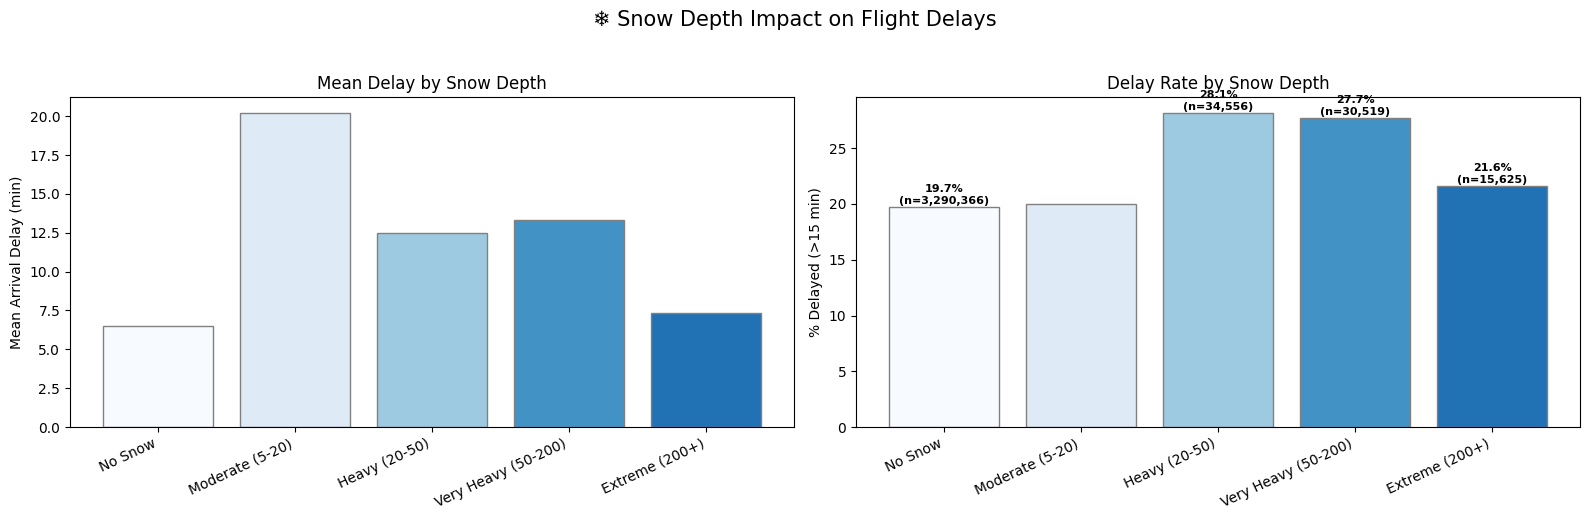


Snow Depth Bin Statistics:
           snow_bin  mean_delay  pct_delayed   count
            No Snow    6.505431    19.690879 3290366
    Moderate (5-20)   20.200000    20.000000      10
      Heavy (20-50)   12.511518    28.142725   34556
Very Heavy (50-200)   13.347652    27.661457   30519
     Extreme (200+)    7.344320    21.574400   15625


In [0]:
if 'snow' in fw_pd.columns:
    snow_data = fw_pd[['snow', fw_arr_delay_col, 'is_delayed']].dropna()
    snow_data = snow_data[snow_data['snow'] >= 0]

    snow_data['snow_bin'] = pd.cut(snow_data['snow'],
                                    bins=[-0.1, 0, 5, 20, 50, 200, 5000],
                                    labels=['No Snow', 'Light (0-5)', 'Moderate (5-20)',
                                            'Heavy (20-50)', 'Very Heavy (50-200)', 'Extreme (200+)'])

    snow_stats = snow_data.groupby('snow_bin', observed=True).agg(
        mean_delay  = (fw_arr_delay_col, 'mean'),
        pct_delayed = ('is_delayed', 'mean'),
        count       = (fw_arr_delay_col, 'count')
    ).reset_index()
    snow_stats['pct_delayed'] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    snow_colors = ['#f7fbff', '#deebf7', '#9ecae1', '#4292c6', '#2171b5', '#084594']

    axes[0].bar(snow_stats['snow_bin'].astype(str), snow_stats['mean_delay'],
                color=snow_colors[:len(snow_stats)], edgecolor='gray')
    axes[0].set_ylabel("Mean Arrival Delay (min)")
    axes[0].set_title("Mean Delay by Snow Depth")
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha='right')

    axes[1].bar(snow_stats['snow_bin'].astype(str), snow_stats['pct_delayed'],
                color=snow_colors[:len(snow_stats)], edgecolor='gray')
    axes[1].set_ylabel("% Delayed (>15 min)")
    axes[1].set_title("Delay Rate by Snow Depth")
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right')
    for j, row in snow_stats.iterrows():
        if row['count'] > 10:
            axes[1].text(j, row['pct_delayed'] + 0.3, f"{row['pct_delayed']:.1f}%\n(n={row['count']:,})",
                         ha='center', fontsize=8, fontweight='bold')

    plt.suptitle("❄️ Snow Depth Impact on Flight Delays", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    print("\nSnow Depth Bin Statistics:")
    print(snow_stats.to_string(index=False))

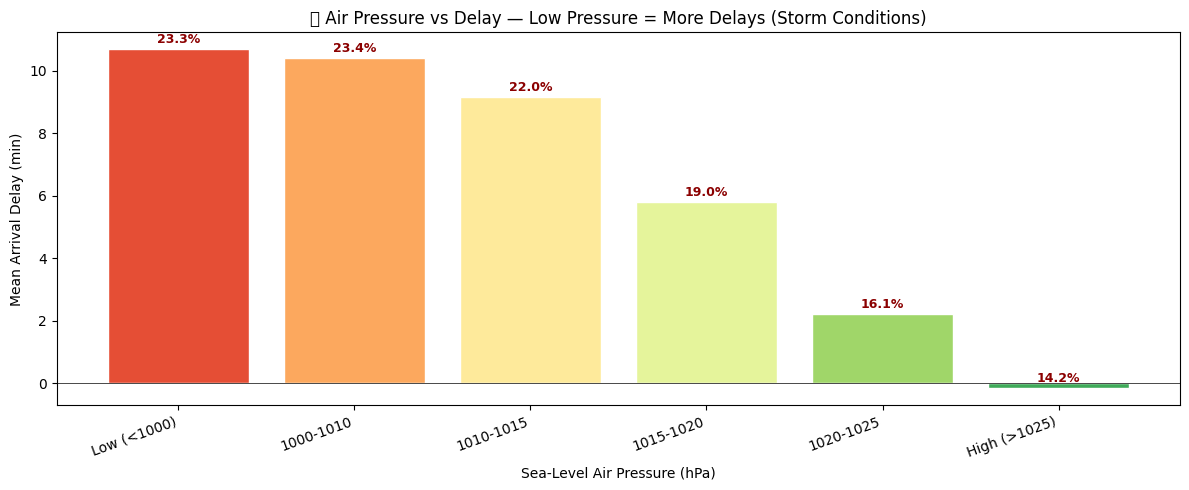


Pressure Bin Statistics:
    pres_bin  mean_delay  pct_delayed   count
 Low (<1000)   10.693138    23.255980   27967
   1000-1010   10.400572    23.446150  520610
   1010-1015    9.167484    21.969538 1055070
   1015-1020    5.805862    18.977150 1011527
   1020-1025    2.210277    16.091183  516985
High (>1025)   -0.174069    14.202840  238917


In [0]:
if 'pres' in fw_pd.columns:
    pres_data = fw_pd[['pres', fw_arr_delay_col, 'is_delayed']].dropna()
    pres_data = pres_data[(pres_data['pres'] > 950) & (pres_data['pres'] < 1060)]  # valid range

    pres_data['pres_bin'] = pd.cut(pres_data['pres'],
                                    bins=[950, 1000, 1010, 1015, 1020, 1025, 1060],
                                    labels=['Low (<1000)', '1000-1010', '1010-1015',
                                            '1015-1020', '1020-1025', 'High (>1025)'])

    pres_stats = pres_data.groupby('pres_bin', observed=True).agg(
        mean_delay  = (fw_arr_delay_col, 'mean'),
        pct_delayed = ('is_delayed', 'mean'),
        count       = (fw_arr_delay_col, 'count')
    ).reset_index()
    pres_stats['pct_delayed'] *= 100

    fig, ax = plt.subplots(figsize=(12, 5))
    pres_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(pres_stats)))
    ax.bar(pres_stats['pres_bin'].astype(str), pres_stats['mean_delay'],
           color=pres_colors, edgecolor='white')
    ax.set_ylabel("Mean Arrival Delay (min)")
    ax.set_xlabel("Sea-Level Air Pressure (hPa)")
    ax.set_title("🌀 Air Pressure vs Delay — Low Pressure = More Delays (Storm Conditions)")
    ax.axhline(y=0, color='black', linewidth=0.5)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')
    for j, row in pres_stats.iterrows():
        ax.text(j, row['mean_delay'] + 0.2, f"{row['pct_delayed']:.1f}%",
                ha='center', fontsize=9, fontweight='bold', color='darkred')
    plt.tight_layout()
    plt.show()

    print("\nPressure Bin Statistics:")
    print(pres_stats.to_string(index=False))

In [0]:
def min_max_norm(s):
    """Normalize series to [0, 1]"""
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

fw_pd['severity_temp'] = 0.0
if 'tavg' in fw_pd.columns:
    # Extreme cold & extreme heat both risky → distance from comfortable 20°C
    fw_pd['severity_temp'] = min_max_norm(np.abs(fw_pd['tavg'].fillna(20) - 20))

fw_pd['severity_prcp'] = 0.0
if 'prcp' in fw_pd.columns:
    fw_pd['severity_prcp'] = min_max_norm(fw_pd['prcp'].fillna(0).clip(0))

fw_pd['severity_wind'] = 0.0
if 'wspd' in fw_pd.columns:
    fw_pd['severity_wind'] = min_max_norm(fw_pd['wspd'].fillna(0).clip(0))

fw_pd['severity_snow'] = 0.0
if 'snow' in fw_pd.columns:
    fw_pd['severity_snow'] = min_max_norm(fw_pd['snow'].fillna(0).clip(0))

fw_pd['severity_pres'] = 0.0
if 'pres' in fw_pd.columns:
    # Low pressure = bad weather → invert
    fw_pd['severity_pres'] = min_max_norm(1060 - fw_pd['pres'].fillna(1013).clip(950, 1060))

# Composite index (weighted average)
fw_pd['weather_severity'] = (
    0.15 * fw_pd['severity_temp'] +
    0.30 * fw_pd['severity_prcp'] +
    0.25 * fw_pd['severity_wind'] +
    0.15 * fw_pd['severity_snow'] +
    0.15 * fw_pd['severity_pres']
)

print("Weather Severity Index created (0 = calm, 1 = extreme)")
print(f"  Mean:   {fw_pd['weather_severity'].mean():.3f}")
print(f"  Median: {fw_pd['weather_severity'].median():.3f}")
print(f"  Max:    {fw_pd['weather_severity'].max():.3f}")

Weather Severity Index created (0 = calm, 1 = extreme)
  Mean:   0.136
  Median: 0.131
  Max:    0.494


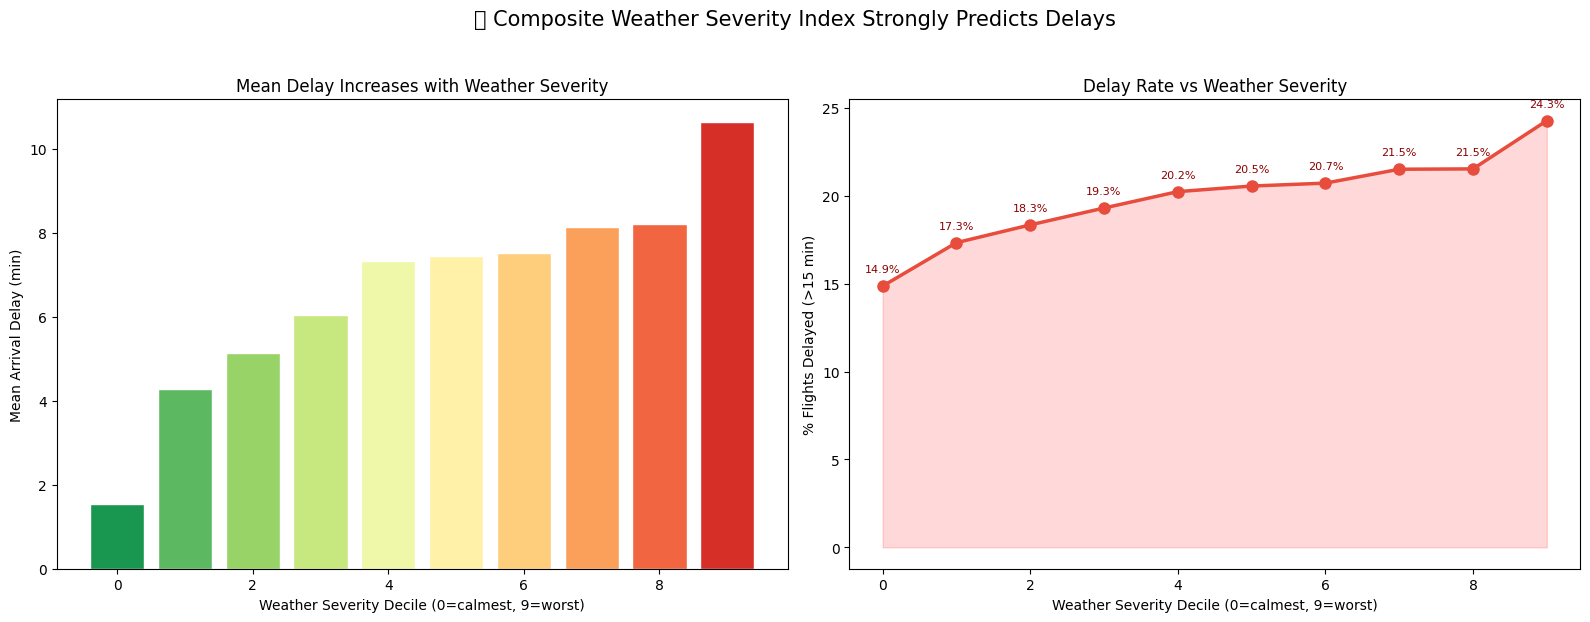


🔗 Correlation(Weather Severity, Arrival Delay) = 0.0421


In [0]:
fw_pd['severity_bin'] = pd.qcut(fw_pd['weather_severity'], q=10, labels=False, duplicates='drop')

severity_stats = fw_pd.groupby('severity_bin').agg(
    mean_severity = ('weather_severity', 'mean'),
    mean_delay    = (fw_arr_delay_col, 'mean'),
    pct_delayed   = ('is_delayed', 'mean'),
    count         = (fw_arr_delay_col, 'count')
).reset_index()
severity_stats['pct_delayed'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean delay by severity decile
ax = axes[0]
severity_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(severity_stats)))
ax.bar(severity_stats['severity_bin'], severity_stats['mean_delay'],
       color=severity_colors, edgecolor='white')
ax.set_xlabel("Weather Severity Decile (0=calmest, 9=worst)")
ax.set_ylabel("Mean Arrival Delay (min)")
ax.set_title("Mean Delay Increases with Weather Severity")
ax.axhline(y=0, color='black', linewidth=0.5)

# % delayed by severity decile
ax = axes[1]
ax.plot(severity_stats['severity_bin'], severity_stats['pct_delayed'],
        'o-', color='#e74c3c', linewidth=2.5, markersize=8)
ax.fill_between(severity_stats['severity_bin'], severity_stats['pct_delayed'],
                alpha=0.15, color='red')
ax.set_xlabel("Weather Severity Decile (0=calmest, 9=worst)")
ax.set_ylabel("% Flights Delayed (>15 min)")
ax.set_title("Delay Rate vs Weather Severity")

for _, row in severity_stats.iterrows():
    ax.annotate(f"{row['pct_delayed']:.1f}%",
                (row['severity_bin'], row['pct_delayed']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8, color='darkred')

plt.suptitle("📈 Composite Weather Severity Index Strongly Predicts Delays",
             fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# Correlation
sev_corr = fw_pd[['weather_severity', fw_arr_delay_col]].corr().iloc[0, 1]
print(f"\n🔗 Correlation(Weather Severity, Arrival Delay) = {sev_corr:.4f}")

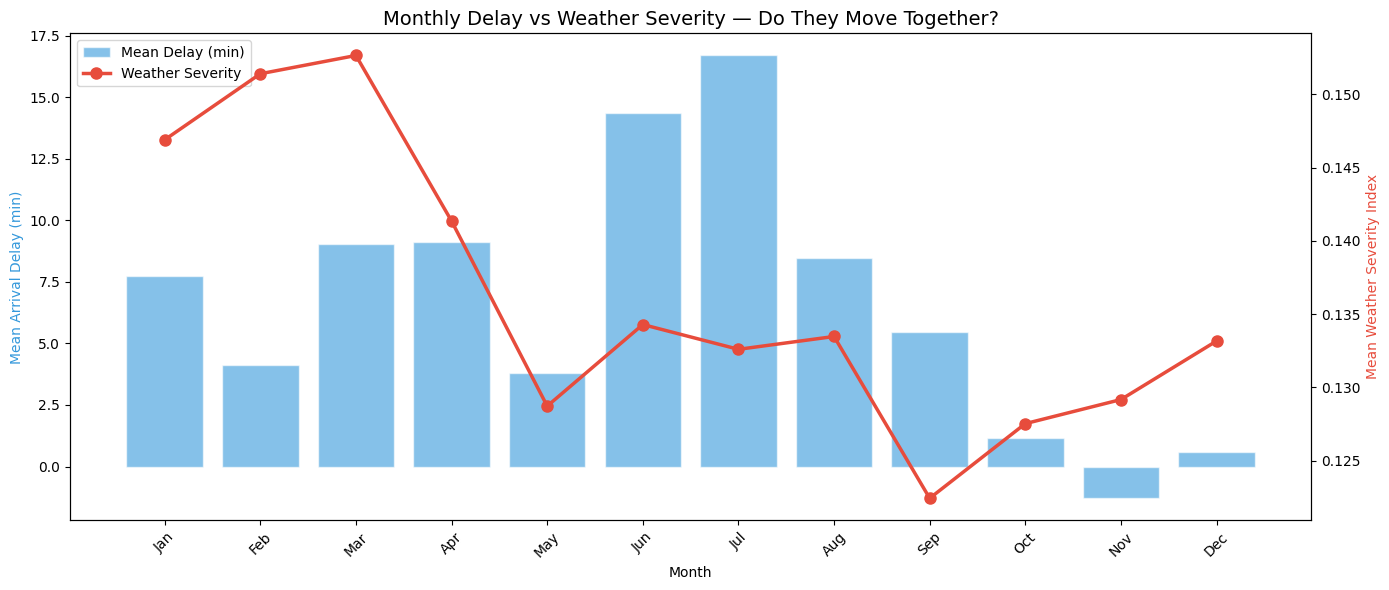

In [0]:
fw_pd['flightdate'] = pd.to_datetime(fw_pd['flightdate'], errors='coerce')
fw_pd['month'] = fw_pd['flightdate'].dt.month

month_names_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                   7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_weather = fw_pd.groupby('month').agg(
    mean_delay    = (fw_arr_delay_col, 'mean'),
    mean_severity = ('weather_severity', 'mean'),
    mean_prcp     = ('prcp', 'mean') if 'prcp' in fw_pd.columns else (fw_arr_delay_col, 'count'),
    mean_wspd     = ('wspd', 'mean') if 'wspd' in fw_pd.columns else (fw_arr_delay_col, 'count'),
    mean_tavg     = ('tavg', 'mean') if 'tavg' in fw_pd.columns else (fw_arr_delay_col, 'count'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#3498db'
color2 = '#e74c3c'

ax1.bar(monthly_weather['month'], monthly_weather['mean_delay'],
        color=color1, alpha=0.6, edgecolor='white', label='Mean Delay (min)')
ax1.set_xlabel("Month")
ax1.set_ylabel("Mean Arrival Delay (min)", color=color1)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names_map[m] for m in range(1, 13)], rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_weather['month'], monthly_weather['mean_severity'],
         'o-', color=color2, linewidth=2.5, markersize=8, label='Weather Severity')
ax2.set_ylabel("Mean Weather Severity Index", color=color2)

ax1.set_title("Monthly Delay vs Weather Severity — Do They Move Together?", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


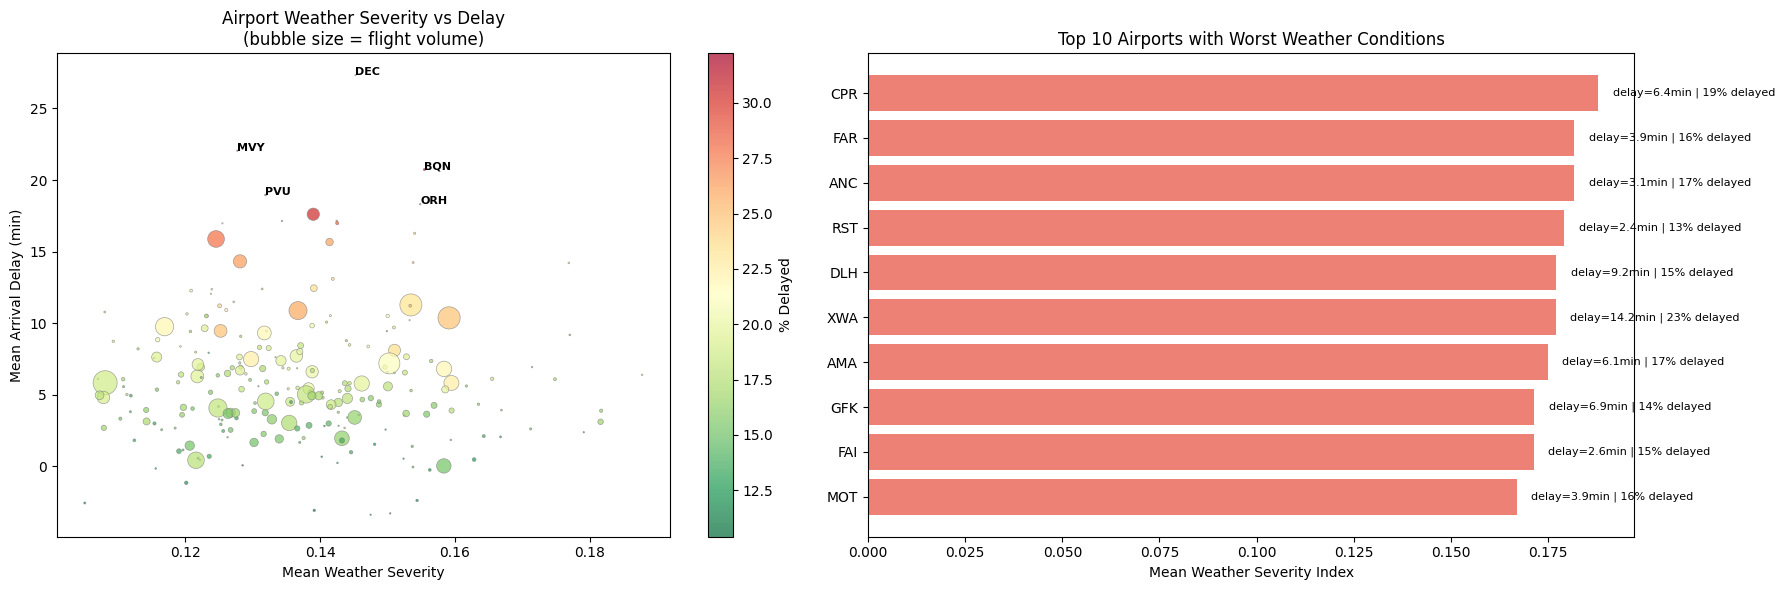


Top 10 Worst-Weather Airports:
dep_airport  mean_severity  mean_delay  pct_delayed  mean_prcp  mean_wspd  flights
        CPR       0.187816    6.396055    18.512898   0.989833  19.645220      659
        FAR       0.181733    3.888925    16.466385   1.598603  16.709711     3079
        ANC       0.181645    3.114101    16.666667   1.852952  10.426056     8808
        RST       0.179144    2.385103    12.836767   2.251506  18.025515      631
        DLH       0.177078    9.184096    15.359477   2.443355  15.342702      918
        XWA       0.176934   14.211976    22.634731   1.420838  18.360000      835
        AMA       0.174868    6.088099    17.078825   1.268856  20.652975     2588
        GFK       0.171471    6.930818    14.465409   1.340409  16.382390      636
        FAI       0.171265    2.614765    15.100671   0.774564   6.585570     1490
        MOT       0.166922    3.929930    15.615616   1.086887  16.024424      999


In [0]:
origin_col_fw = None
for c in fw_pd.columns:
    if 'origin' in c or 'dep_airport' in c:
        origin_col_fw = c
        break

if origin_col_fw:
    airport_weather = fw_pd.groupby(origin_col_fw).agg(
        mean_delay    = (fw_arr_delay_col, 'mean'),
        mean_severity = ('weather_severity', 'mean'),
        pct_delayed   = ('is_delayed', 'mean'),
        mean_prcp     = ('prcp', 'mean'),
        mean_wspd     = ('wspd', 'mean'),
        flights       = (fw_arr_delay_col, 'count')
    ).reset_index()
    airport_weather['pct_delayed'] *= 100

    # Filter to airports with enough flights
    airport_weather = airport_weather[airport_weather['flights'] >= 500]

    # Top 10 worst weather
    top_worst = airport_weather.nlargest(10, 'mean_severity')

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Severity vs Delay scatter for all airports
    ax = axes[0]
    sc = ax.scatter(airport_weather['mean_severity'], airport_weather['mean_delay'],
                    s=airport_weather['flights'] / airport_weather['flights'].max() * 300,
                    c=airport_weather['pct_delayed'], cmap='RdYlGn_r',
                    edgecolors='gray', linewidth=0.5, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='% Delayed')
    ax.set_xlabel("Mean Weather Severity")
    ax.set_ylabel("Mean Arrival Delay (min)")
    ax.set_title("Airport Weather Severity vs Delay\n(bubble size = flight volume)")

    # Annotate extremes
    for _, row in airport_weather.nlargest(5, 'mean_delay').iterrows():
        ax.annotate(row[origin_col_fw], (row['mean_severity'], row['mean_delay']),
                    fontsize=8, fontweight='bold')

    # Top 10 worst weather airports bar chart
    ax = axes[1]
    y_pos = range(len(top_worst))
    ax.barh(y_pos, top_worst['mean_severity'], color='#e74c3c', alpha=0.7, label='Severity')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_worst[origin_col_fw])
    ax.set_xlabel("Mean Weather Severity Index")
    ax.set_title("Top 10 Airports with Worst Weather Conditions")
    ax.invert_yaxis()

    # Add delay info
    for j, (_, row) in enumerate(top_worst.iterrows()):
        ax.text(row['mean_severity'] + 0.002, j,
                f"  delay={row['mean_delay']:.1f}min | {row['pct_delayed']:.0f}% delayed",
                va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print("\nTop 10 Worst-Weather Airports:")
    print(top_worst[[origin_col_fw, 'mean_severity', 'mean_delay', 'pct_delayed',
                     'mean_prcp', 'mean_wspd', 'flights']]
          .to_string(index=False))
else:
    print("Could not find origin/airport column in joined data")